In [ ]:
# ============================================================
# SUPPLY CHAIN DISRUPTION PREDICTOR
# Cell 1 — Install libraries
# ============================================================
# These three are not pre-installed in Colab so we install them first.
# xgboost       → gradient boosted tree model
# shap          → explains individual predictions
# imbalanced-learn → handles class imbalance in training

!pip install xgboost shap imbalanced-learn --quiet

# Verify all libraries load correctly
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import sklearn
import xgboost as xgb
import shap
import warnings
warnings.filterwarnings('ignore')

print("=" * 45)
print("  LIBRARY VERSIONS")
print("=" * 45)
print(f"  pandas      : {pd.__version__}")
print(f"  numpy       : {np.__version__}")
print(f"  matplotlib  : {matplotlib.__version__}")
print(f"  sklearn     : {sklearn.__version__}")
print(f"  xgboost     : {xgb.__version__}")
print(f"  shap        : {shap.__version__}")
print()

  LIBRARY VERSIONS
  pandas      : 2.2.2
  numpy       : 2.0.2
  matplotlib  : 3.10.0
  sklearn     : 1.6.1
  xgboost     : 3.2.0
  shap        : 0.51.0



In [ ]:
# ============================================================
# Cell 2 — Upload and load the dataset
# ============================================================
from google.colab import files
import io

print("👆 Upload: DataCoSupplyChainDataset.csv")
uploaded = files.upload()

filename = list(uploaded.keys())[0]
df_raw = pd.read_csv(io.BytesIO(uploaded[filename]), encoding='latin1')

print(f"\n✅ Loaded: {filename}")
print(f"\n{'='*50}")
print(f"  RAW DATA QUALITY REPORT")
print(f"{'='*50}")
print(f"  Shape          : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"  Memory         : {df_raw.memory_usage(deep=True).sum()/1024**2:.1f} MB")
print(f"  Duplicate rows : {df_raw.duplicated().sum()}")

print(f"\n  MISSING VALUES:")
nulls = df_raw.isnull().sum()
nulls = nulls[nulls > 0].sort_values(ascending=False)
for col, n in nulls.items():
    print(f"    {col:<35} {n:>7,}  ({n/len(df_raw)*100:.1f}%)")

print(f"\n  DATE COLUMN TYPES (should be object/str — we fix in Cell 3):")
for c in ['order date (DateOrders)', 'shipping date (DateOrders)']:
    print(f"    {c:<35} {df_raw[c].dtype}")

print(f"\n  TARGET VARIABLE — Late_delivery_risk:")
vc = df_raw['Late_delivery_risk'].value_counts()
print(f"    Late (1)    : {vc[1]:>6,}  ({vc[1]/len(df_raw)*100:.1f}%)")
print(f"    On time (0) : {vc[0]:>6,}  ({vc[0]/len(df_raw)*100:.1f}%)")

print(f"\n  ORDER STATUS (we will remove FRAUD + CANCELED):")
for status, count in df_raw['Order Status'].value_counts().items():
    print(f"    {status:<25} {count:>6,}")


👆 Upload: DataCoSupplyChainDataset.csv


Saving DataCoSupplyChainDataset.csv to DataCoSupplyChainDataset.csv

✅ Loaded: DataCoSupplyChainDataset.csv

  RAW DATA QUALITY REPORT
  Shape          : 180,519 rows × 53 columns
  Memory         : 298.9 MB
  Duplicate rows : 0

  MISSING VALUES:
    Product Description                 180,519  (100.0%)
    Order Zipcode                       155,679  (86.2%)
    Customer Lname                            8  (0.0%)
    Customer Zipcode                          3  (0.0%)

  DATE COLUMN TYPES (should be object/str — we fix in Cell 3):
    order date (DateOrders)             object
    shipping date (DateOrders)          object

  TARGET VARIABLE — Late_delivery_risk:
    Late (1)    : 98,977  (54.8%)
    On time (0) : 81,542  (45.2%)

  ORDER STATUS (we will remove FRAUD + CANCELED):
    COMPLETE                  59,491
    PENDING_PAYMENT           39,832
    PROCESSING                21,902
    PENDING                   20,227
    CLOSED                    19,616
    ON_HOLD           

In [ ]:
# ============================================================
# Cell 3 — Data Cleaning
# ============================================================
import pandas as pd
import numpy as np

df = df_raw.copy()  # always work on a copy, preserve df_raw

print("Starting data cleaning...")
print(f"  Shape before : {df.shape[0]:,} rows × {df.shape[1]} columns")

# ── Step 1: Drop useless, PII and broken columns ──────────────
DROP_COLS = [
    'Product Description',   # 100% null
    'Order Zipcode',         # 86% null, not analytically useful
    'Product Status',        # only 1 unique value (all zeros)
    'Customer Email',        # 1 unique value — anonymised/corrupted
    'Customer Password',     # 1 unique value — anonymised/corrupted
    'Product Image',         # URL strings, no value
    'Customer Fname',        # PII not needed
    'Customer Lname',        # PII not needed
    'Customer Street',       # PII not needed
]
df.drop(columns=DROP_COLS, inplace=True)
print(f"\n  ✅ Step 1 — Dropped {len(DROP_COLS)} useless/PII columns")

# ── Step 2: Fix date columns ──────────────────────────────────
df['order_date']    = pd.to_datetime(df['order date (DateOrders)'],   errors='coerce')
df['shipping_date'] = pd.to_datetime(df['shipping date (DateOrders)'], errors='coerce')
df.drop(columns=['order date (DateOrders)', 'shipping date (DateOrders)'], inplace=True)
print(f"  ✅ Step 2 — Parsed dates: order_date, shipping_date → datetime64")

# ── Step 3: Remove SUSPECTED_FRAUD and CANCELED orders ───────
before = len(df)
df = df[~df['Order Status'].isin(['SUSPECTED_FRAUD', 'CANCELED'])]
removed = before - len(df)
print(f"  ✅ Step 3 — Removed {removed:,} FRAUD + CANCELED rows")

# ── Step 4: Handle zero-day scheduled orders (Same Day) ───────
# 9,737 Same Day orders have scheduled=0 → causes division by zero
# We flag them and set scheduled to 1 to keep them usable
df['is_same_day'] = (df['Days for shipment (scheduled)'] == 0).astype(int)
df.loc[df['Days for shipment (scheduled)'] == 0, 'Days for shipment (scheduled)'] = 1
zero_actual = (df['Days for shipping (real)'] == 0).sum()
df.loc[df['Days for shipping (real)'] == 0, 'Days for shipping (real)'] = 1
print(f"  ✅ Step 4 — Flagged {df['is_same_day'].sum():,} Same Day orders, fixed zero values")

# ── Step 5: Clip profit outliers (1st–99th percentile) ────────
p01 = df['Order Profit Per Order'].quantile(0.01)
p99 = df['Order Profit Per Order'].quantile(0.99)
before_clip = ((df['Order Profit Per Order'] < p01) |
               (df['Order Profit Per Order'] > p99)).sum()
df['Order Profit Per Order'] = df['Order Profit Per Order'].clip(p01, p99)
print(f"  ✅ Step 5 — Clipped {before_clip:,} profit outliers to [{p01:.1f}, {p99:.1f}]")

# ── Step 6: Fill remaining tiny nulls ─────────────────────────
df['Customer Zipcode'] = df['Customer Zipcode'].fillna(
    df['Customer Zipcode'].median())
print(f"  ✅ Step 6 — Filled 3 Customer Zipcode nulls with median")

# ── Step 7: Reset index cleanly ───────────────────────────────
df.reset_index(drop=True, inplace=True)
print(f"\n  Shape after  : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"  Rows removed : {len(df_raw) - len(df):,}")

Starting data cleaning...
  Shape before : 180,519 rows × 53 columns

  ✅ Step 1 — Dropped 9 useless/PII columns
  ✅ Step 2 — Parsed dates: order_date, shipping_date → datetime64
  ✅ Step 3 — Removed 7,754 FRAUD + CANCELED rows
  ✅ Step 4 — Flagged 9,293 Same Day orders, fixed zero values
  ✅ Step 5 — Clipped 3,442 profit outliers to [-412.6, 184.2]
  ✅ Step 6 — Filled 3 Customer Zipcode nulls with median

  Shape after  : 172,765 rows × 45 columns
  Rows removed : 7,754


In [ ]:
# ============================================================
# Cell 4 — Cleaning Validation
# ============================================================
print("=" * 50)
print("  CLEANING VALIDATION REPORT")
print("=" * 50)

# ── Check 1: Zero nulls in all columns we will use ───────────
critical_cols = [
    'Days for shipping (real)', 'Days for shipment (scheduled)',
    'Order Profit Per Order', 'Order Item Discount Rate',
    'Order Item Profit Ratio', 'Order Item Quantity',
    'Sales', 'Order Item Total', 'Order Item Product Price',
    'Shipping Mode', 'Order Region', 'Market',
    'Customer Segment', 'Category Name', 'Department Name',
    'Late_delivery_risk', 'order_date', 'is_same_day', 'Type'
]
print("\n  NULL CHECK on model columns:")
all_clean = True
for col in critical_cols:
    n = df[col].isnull().sum()
    status = "✅" if n == 0 else "❌"
    if n > 0:
        all_clean = False
    print(f"    {status} {col:<40} nulls: {n}")

# ── Check 2: Date columns are datetime ───────────────────────
print(f"\n  DATE TYPE CHECK:")
for col in ['order_date', 'shipping_date']:
    dtype = str(df[col].dtype)
    ok = "✅" if 'datetime' in dtype else "❌"
    print(f"    {ok} {col:<20} dtype: {dtype}")

# ── Check 3: No zero scheduled days ──────────────────────────
zero_sched = (df['Days for shipment (scheduled)'] == 0).sum()
zero_real  = (df['Days for shipping (real)'] == 0).sum()
print(f"\n  ZERO-DAY CHECK:")
print(f"    {'✅' if zero_sched==0 else '❌'} Scheduled days with zero : {zero_sched}")
print(f"    {'✅' if zero_real==0 else '❌'} Actual days with zero    : {zero_real}")

# ── Check 4: Profit within clipped range ─────────────────────
p_min = df['Order Profit Per Order'].min()
p_max = df['Order Profit Per Order'].max()
print(f"\n  PROFIT RANGE CHECK:")
print(f"    Min profit : ${p_min:.2f}  (was -$4,274 before clipping)")
print(f"    Max profit : ${p_max:.2f}  (was +$911 before clipping)")

# ── Check 5: FRAUD and CANCELED are gone ─────────────────────
remaining_bad = df['Order Status'].isin(['SUSPECTED_FRAUD','CANCELED']).sum()
print(f"\n  ORDER STATUS CHECK:")
print(f"    {'✅' if remaining_bad==0 else '❌'} FRAUD + CANCELED remaining : {remaining_bad}")
for status, count in df['Order Status'].value_counts().items():
    print(f"       {status:<25} {count:>6,}")

# ── Check 6: Target variable balance ─────────────────────────
vc = df['Late_delivery_risk'].value_counts()
print(f"\n  TARGET BALANCE (after cleaning):")
print(f"    Late (1)    : {vc[1]:>6,}  ({vc[1]/len(df)*100:.1f}%)")
print(f"    On time (0) : {vc[0]:>6,}  ({vc[0]/len(df)*100:.1f}%)")

# ── Final summary ─────────────────────────────────────────────
print(f"\n{'='*50}")
print(f"  Final clean dataset : {df.shape[0]:,} rows × {df.shape[1]} columns")
if all_clean:
    print(f"  ✅ All model columns are null-free")
print(f"  ✅ Ready for feature engineering")
print(f"{'='*50}")

  CLEANING VALIDATION REPORT

  NULL CHECK on model columns:
    ✅ Days for shipping (real)                 nulls: 0
    ✅ Days for shipment (scheduled)            nulls: 0
    ✅ Order Profit Per Order                   nulls: 0
    ✅ Order Item Discount Rate                 nulls: 0
    ✅ Order Item Profit Ratio                  nulls: 0
    ✅ Order Item Quantity                      nulls: 0
    ✅ Sales                                    nulls: 0
    ✅ Order Item Total                         nulls: 0
    ✅ Order Item Product Price                 nulls: 0
    ✅ Shipping Mode                            nulls: 0
    ✅ Order Region                             nulls: 0
    ✅ Market                                   nulls: 0
    ✅ Customer Segment                         nulls: 0
    ✅ Category Name                            nulls: 0
    ✅ Department Name                          nulls: 0
    ✅ Late_delivery_risk                       nulls: 0
    ✅ order_date                           

In [ ]:
# ============================================================
# Cell 5 — Exploratory Data Analysis (Stats)
# ============================================================
print("=" * 55)
print("  EXPLORATORY DATA ANALYSIS")
print("=" * 55)

# ── Delivery performance overview ────────────────────────────
print("\n  1. DELIVERY STATUS BREAKDOWN:")
for status, count in df['Delivery Status'].value_counts().items():
    pct = count / len(df) * 100
    bar = '█' * int(pct / 2)
    print(f"    {status:<25} {count:>6,}  ({pct:.1f}%)  {bar}")

# ── Late rate by shipping mode ────────────────────────────────
print("\n  2. LATE DELIVERY RATE BY SHIPPING MODE:")
mode_stats = df.groupby('Shipping Mode').agg(
    late_rate  = ('Late_delivery_risk', 'mean'),
    count      = ('Late_delivery_risk', 'count'),
    avg_profit = ('Order Profit Per Order', 'mean')
).reset_index().sort_values('late_rate', ascending=False)
for _, row in mode_stats.iterrows():
    bar = '█' * int(row['late_rate'] * 50)
    print(f"    {row['Shipping Mode']:<18} {row['late_rate']*100:.1f}%  "
          f"({row['count']:>6,} orders)  avg profit: ${row['avg_profit']:.2f}  {bar}")

# ── Late rate by market ───────────────────────────────────────
print("\n  3. LATE DELIVERY RATE BY MARKET:")
market_stats = df.groupby('Market').agg(
    late_rate  = ('Late_delivery_risk', 'mean'),
    count      = ('Late_delivery_risk', 'count'),
    avg_profit = ('Order Profit Per Order', 'mean')
).reset_index().sort_values('late_rate', ascending=False)
for _, row in market_stats.iterrows():
    print(f"    {row['Market']:<15} {row['late_rate']*100:.1f}%  "
          f"({row['count']:>6,} orders)  avg profit: ${row['avg_profit']:.2f}")

# ── Top 10 highest-risk regions ──────────────────────────────
print("\n  4. TOP 10 HIGHEST-RISK REGIONS:")
region_stats = df.groupby('Order Region').agg(
    late_rate  = ('Late_delivery_risk', 'mean'),
    count      = ('Late_delivery_risk', 'count'),
    avg_profit = ('Order Profit Per Order', 'mean')
).reset_index().sort_values('late_rate', ascending=False).head(10)
for _, row in region_stats.iterrows():
    print(f"    {row['Order Region']:<22} {row['late_rate']*100:.1f}%  "
          f"({row['count']:>5,} orders)  avg profit: ${row['avg_profit']:.2f}")

# ── Temporal risk by month ────────────────────────────────────
print("\n  5. LATE RATE BY MONTH (Temporal Risk):")
df['order_month'] = df['order_date'].dt.month
month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
               7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
monthly = df.groupby('order_month')['Late_delivery_risk'].mean()
for m, rate in monthly.items():
    bar = '█' * int(rate * 50)
    flag = ' ← PEAK' if rate >= 0.555 else ''
    print(f"    {month_names[m]}  {rate*100:.1f}%  {bar}{flag}")

# ── Profit analysis ───────────────────────────────────────────
print("\n  6. PROFIT DISTRIBUTION:")
print(f"    Mean profit per order  : ${df['Order Profit Per Order'].mean():.2f}")
print(f"    Median profit          : ${df['Order Profit Per Order'].median():.2f}")
print(f"    Loss-making orders     : "
      f"{(df['Order Profit Per Order'] < 0).sum():,}  "
      f"({(df['Order Profit Per Order'] < 0).mean()*100:.1f}%)")
print(f"    Avg profit — Late      : "
      f"${df[df['Late_delivery_risk']==1]['Order Profit Per Order'].mean():.2f}")
print(f"    Avg profit — On time   : "
      f"${df[df['Late_delivery_risk']==0]['Order Profit Per Order'].mean():.2f}")

# ── Delivery days analysis ────────────────────────────────────
print("\n  7. DELIVERY DAYS ANALYSIS:")
print(f"    Scheduled days — mean  : {df['Days for shipment (scheduled)'].mean():.2f}")
print(f"    Actual days — mean     : {df['Days for shipping (real)'].mean():.2f}")
print(f"    Mean performance gap   : "
      f"{(df['Days for shipping (real)'] - df['Days for shipment (scheduled)']).mean():.2f} days")
print(f"    Orders delivered early : "
      f"{(df['Days for shipping (real)'] < df['Days for shipment (scheduled)']).sum():,}")
print(f"    Orders delivered late  : "
      f"{(df['Days for shipping (real)'] > df['Days for shipment (scheduled)']).sum():,}")
print(f"    Orders on time exactly : "
      f"{(df['Days for shipping (real)'] == df['Days for shipment (scheduled)']).sum():,}")


  EXPLORATORY DATA ANALYSIS

  1. DELIVERY STATUS BREAKDOWN:
    Late delivery             98,977  (57.3%)  ████████████████████████████
    Advance shipping          41,592  (24.1%)  ████████████
    Shipping on time          32,196  (18.6%)  █████████

  2. LATE DELIVERY RATE BY SHIPPING MODE:
    First Class        100.0%  (26,513 orders)  avg profit: $24.55  ██████████████████████████████████████████████████
    Second Class       79.8%  (33,806 orders)  avg profit: $23.02  ███████████████████████████████████████
    Same Day           47.9%  ( 9,293 orders)  avg profit: $22.18  ███████████████████████
    Standard Class     39.8%  (103,153 orders)  avg profit: $23.36  ███████████████████

  3. LATE DELIVERY RATE BY MARKET:
    Europe          57.7%  (48,090 orders)  avg profit: $24.67
    USCA            57.4%  (24,627 orders)  avg profit: $23.32
    Pacific Asia    57.4%  (39,585 orders)  avg profit: $22.25
    LATAM           56.9%  (49,309 orders)  avg profit: $23.20
    Africa

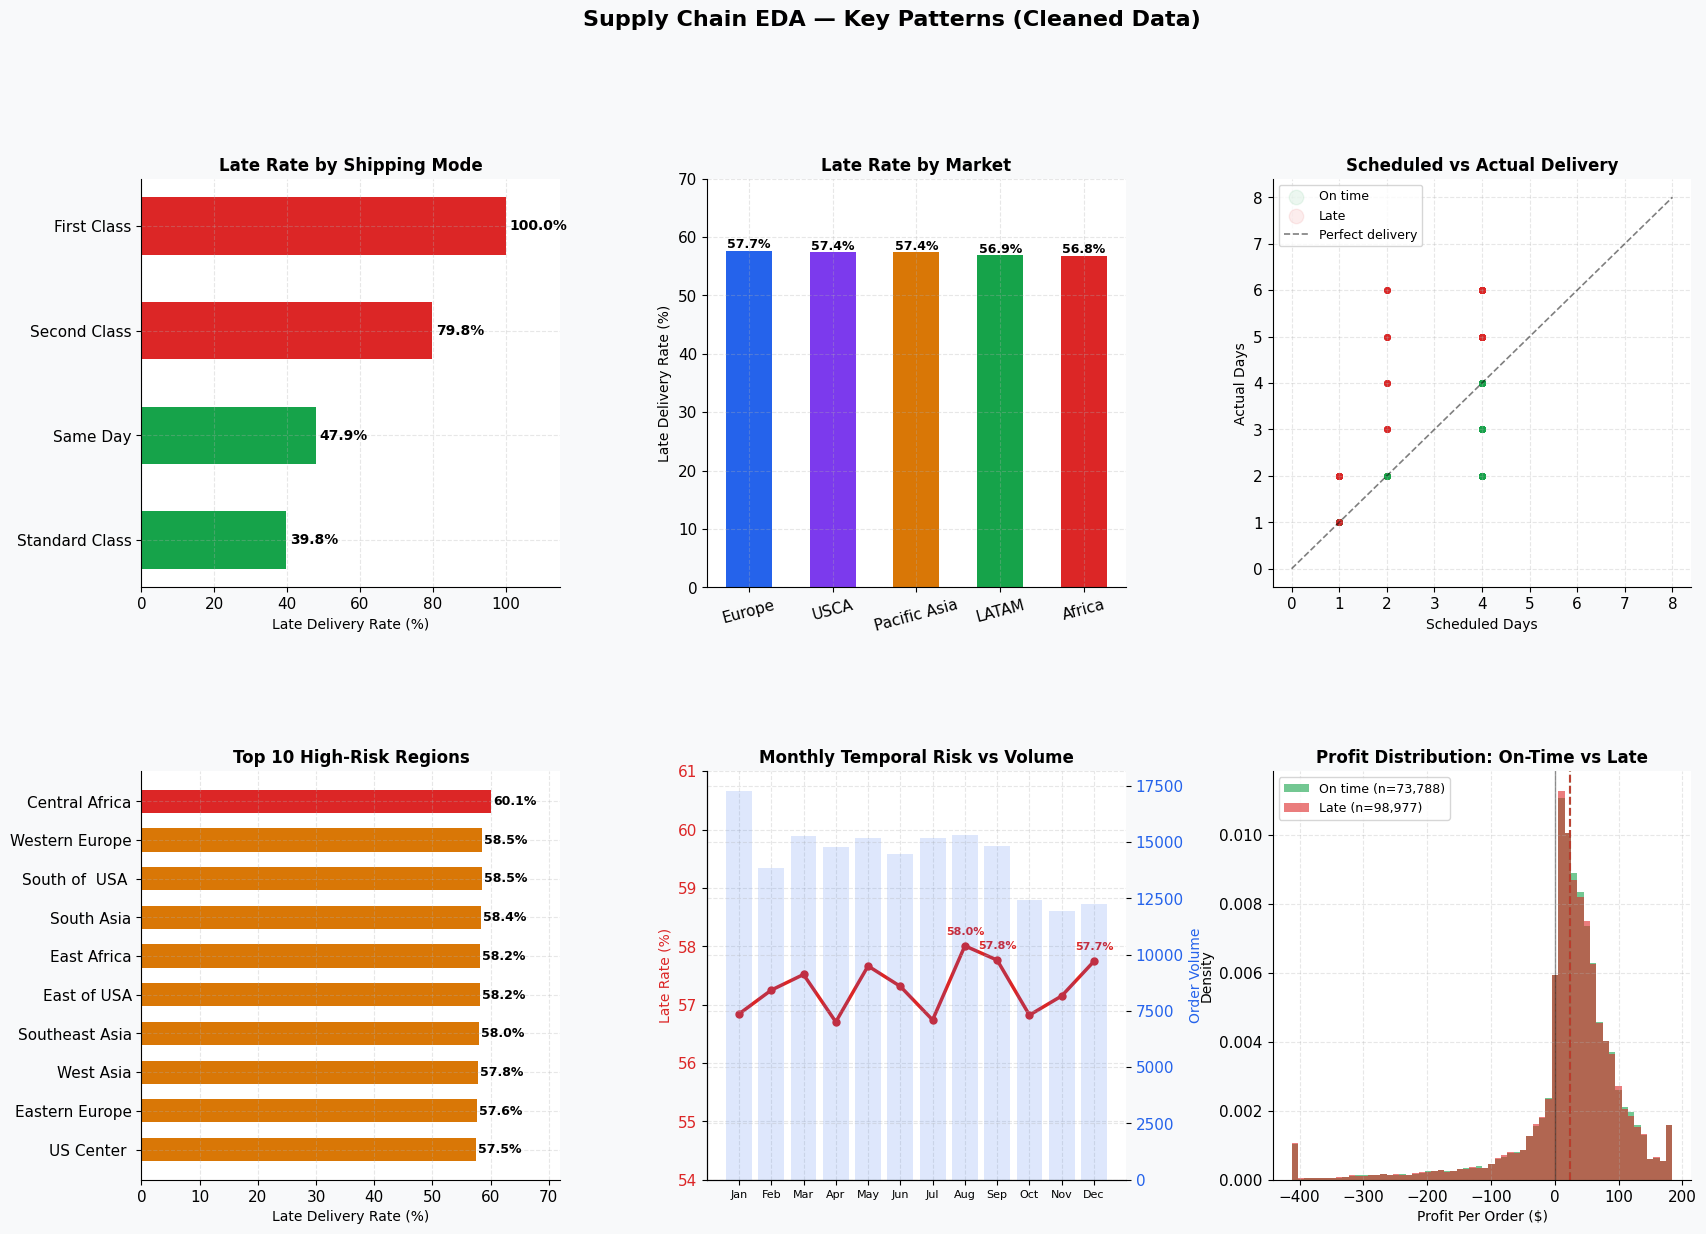

✅ EDA charts saved as eda_overview.png

Key findings confirmed:
  → First Class late rate   : 100.0%
  → Standard Class late rate: 39.8%
  → Highest risk region     : Central Africa
  → Peak risk month         : Aug (58.0%)
  → Mean performance gap    : 0.54 days


In [ ]:
# ============================================================
# Cell 6 — EDA Charts
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#F8F9FA',
    'axes.facecolor':   '#FFFFFF',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'grid.linestyle':   '--',
    'font.size':        11,
    'axes.titlesize':   12,
    'axes.titleweight': 'bold',
    'axes.labelsize':   10,
})

COLORS = {
    'red':    '#DC2626',
    'blue':   '#2563EB',
    'green':  '#16A34A',
    'amber':  '#D97706',
    'purple': '#7C3AED',
    'gray':   '#6B7280',
}

fig = plt.figure(figsize=(20, 13))
fig.suptitle('Supply Chain EDA — Key Patterns (Cleaned Data)',
             fontsize=16, fontweight='bold', y=1.01)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── Chart 1: Late rate by Shipping Mode ──────────────────────
ax1 = fig.add_subplot(gs[0, 0])
modes = mode_stats.sort_values('late_rate')
bar_colors = [COLORS['red'] if r > 0.7 else
              COLORS['amber'] if r > 0.5 else
              COLORS['green'] for r in modes['late_rate']]
bars = ax1.barh(modes['Shipping Mode'], modes['late_rate']*100,
                color=bar_colors, height=0.55)
ax1.set_xlabel('Late Delivery Rate (%)')
ax1.set_title('Late Rate by Shipping Mode')
ax1.set_xlim(0, 115)
for bar, val in zip(bars, modes['late_rate']*100):
    ax1.text(val + 1, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontweight='bold', fontsize=10)

# ── Chart 2: Late rate by Market ─────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
mk = market_stats.sort_values('late_rate', ascending=False)
bar_cols2 = [COLORS['blue'], COLORS['purple'],
             COLORS['amber'], COLORS['green'], COLORS['red']]
bars2 = ax2.bar(mk['Market'], mk['late_rate']*100,
                color=bar_cols2, width=0.55)
ax2.set_ylabel('Late Delivery Rate (%)')
ax2.set_title('Late Rate by Market')
ax2.set_ylim(0, 70)
ax2.tick_params(axis='x', rotation=15)
for bar, val in zip(bars2, mk['late_rate']*100):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontweight='bold', fontsize=9)

# ── Chart 3: Scheduled vs Actual Days scatter ────────────────
ax3 = fig.add_subplot(gs[0, 2])
on_time = df[df['Late_delivery_risk'] == 0].sample(2000, random_state=42)
late_df = df[df['Late_delivery_risk'] == 1].sample(2000, random_state=42)
ax3.scatter(on_time['Days for shipment (scheduled)'],
            on_time['Days for shipping (real)'],
            alpha=0.08, color=COLORS['green'], s=12, label='On time')
ax3.scatter(late_df['Days for shipment (scheduled)'],
            late_df['Days for shipping (real)'],
            alpha=0.08, color=COLORS['red'], s=12, label='Late')
ax3.plot([0, 8], [0, 8], 'k--', lw=1.2, alpha=0.5, label='Perfect delivery')
ax3.set_xlabel('Scheduled Days')
ax3.set_ylabel('Actual Days')
ax3.set_title('Scheduled vs Actual Delivery')
legend = ax3.legend(fontsize=9, markerscale=3)

# ── Chart 4: Top 10 high-risk regions ────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
top10 = df.groupby('Order Region')['Late_delivery_risk'].mean()\
          .sort_values(ascending=False).head(10)
reg_colors = [COLORS['red'] if v > 0.59 else
              COLORS['amber'] if v > 0.57 else
              COLORS['blue'] for v in top10.values]
bars4 = ax4.barh(top10.index[::-1], top10.values[::-1]*100,
                 color=reg_colors[::-1], height=0.6)
ax4.set_xlabel('Late Delivery Rate (%)')
ax4.set_title('Top 10 High-Risk Regions')
ax4.set_xlim(0, 72)
for bar, val in zip(bars4, top10.values[::-1]*100):
    ax4.text(val + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')

# ── Chart 5: Monthly temporal risk ───────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
monthly_rate = df.groupby('order_month')['Late_delivery_risk'].mean() * 100
monthly_vol  = df.groupby('order_month')['Late_delivery_risk'].count()
month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']
ax5_twin = ax5.twinx()
ax5_twin.bar(range(1,13), monthly_vol.values, alpha=0.15,
             color=COLORS['blue'], width=0.8, label='Volume')
ax5.plot(range(1,13), monthly_rate.values, color=COLORS['red'],
         lw=2.5, marker='o', markersize=5, label='Late rate %')
peak_months = monthly_rate.nlargest(3).index.tolist()
for m in peak_months:
    ax5.annotate(f"{monthly_rate[m]:.1f}%",
                 (m, monthly_rate[m]),
                 textcoords='offset points', xytext=(0, 8),
                 ha='center', fontsize=8, color=COLORS['red'],
                 fontweight='bold')
ax5.set_xticks(range(1,13))
ax5.set_xticklabels(month_labels, fontsize=8)
ax5.set_ylabel('Late Rate (%)', color=COLORS['red'])
ax5_twin.set_ylabel('Order Volume', color=COLORS['blue'])
ax5.tick_params(axis='y', labelcolor=COLORS['red'])
ax5_twin.tick_params(axis='y', labelcolor=COLORS['blue'])
ax5.set_title('Monthly Temporal Risk vs Volume')
ax5.set_ylim(54, 61)

# ── Chart 6: Profit distribution by outcome ──────────────────
ax6 = fig.add_subplot(gs[1, 2])
profit_on   = df[df['Late_delivery_risk']==0]['Order Profit Per Order']
profit_late = df[df['Late_delivery_risk']==1]['Order Profit Per Order']
ax6.hist(profit_on,   bins=60, alpha=0.6, color=COLORS['green'],
         density=True, label=f'On time (n={len(profit_on):,})')
ax6.hist(profit_late, bins=60, alpha=0.6, color=COLORS['red'],
         density=True, label=f'Late (n={len(profit_late):,})')
ax6.axvline(profit_on.mean(),   color=COLORS['green'],
            lw=1.5, ls='--', alpha=0.8)
ax6.axvline(profit_late.mean(), color=COLORS['red'],
            lw=1.5, ls='--', alpha=0.8)
ax6.axvline(0, color='black', lw=1, alpha=0.4)
ax6.set_xlabel('Profit Per Order ($)')
ax6.set_ylabel('Density')
ax6.set_title('Profit Distribution: On-Time vs Late')
ax6.legend(fontsize=9)

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ EDA charts saved as eda_overview.png")
print("\nKey findings confirmed:")
print(f"  → First Class late rate   : {df[df['Shipping Mode']=='First Class']['Late_delivery_risk'].mean()*100:.1f}%")
print(f"  → Standard Class late rate: {df[df['Shipping Mode']=='Standard Class']['Late_delivery_risk'].mean()*100:.1f}%")
print(f"  → Highest risk region     : {df.groupby('Order Region')['Late_delivery_risk'].mean().idxmax()}")
print(f"  → Peak risk month         : {month_labels[monthly_rate.idxmax()-1]} ({monthly_rate.max():.1f}%)")
print(f"  → Mean performance gap    : {(df['Days for shipping (real)'] - df['Days for shipment (scheduled)']).mean():.2f} days")

In [ ]:
# ============================================================
# Cell 7 — Feature Engineering: The Four Pillars (Fixed)
# ============================================================
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np

print("=" * 55)
print("  ENGINEERING THE FOUR RESILIENCE PILLARS")
print("=" * 55)

# ── PILLAR 1: Geopolitical Friction Index (GFI) ──────────────
print("\n  PILLAR 1 — Geopolitical Friction Index (GFI)")
region_gfi = df.groupby('Order Region').apply(
    lambda x: (x['Days for shipping (real)'] -
               x['Days for shipment (scheduled)']).mean()
).reset_index()
region_gfi.columns = ['Order Region', 'gfi_raw']
gfi_min = region_gfi['gfi_raw'].min()
gfi_max = region_gfi['gfi_raw'].max()
region_gfi['gfi_score'] = (
    (region_gfi['gfi_raw'] - gfi_min) / (gfi_max - gfi_min)
).round(4)

# Drop if already exists from a previous run then re-add
for col in ['gfi_score']:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)
df = df.merge(region_gfi[['Order Region','gfi_score']],
              on='Order Region', how='left')

print(f"  Top 5 highest friction regions:")
for _, row in region_gfi.sort_values('gfi_score', ascending=False).head(5).iterrows():
    print(f"    {row['Order Region']:<22} GFI={row['gfi_score']:.3f}  "
          f"(avg gap: +{row['gfi_raw']:.2f} days)")

# ── PILLAR 2: Temporal Risk Factor ───────────────────────────
print("\n  PILLAR 2 — Temporal Risk Factor")
df['order_month']   = df['order_date'].dt.month
df['order_quarter'] = df['order_date'].dt.quarter
df['order_dow']     = df['order_date'].dt.dayofweek

monthly_risk    = df.groupby('order_month')['Late_delivery_risk'].mean()
df['temporal_risk'] = df['order_month'].map(monthly_risk).round(4)

month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
               7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
peak_month = monthly_risk.idxmax()
low_month  = monthly_risk.idxmin()
print(f"  Peak risk  : {month_names[peak_month]} ({monthly_risk.max()*100:.1f}%) ← congestion season")
print(f"  Low risk   : {month_names[low_month]}  ({monthly_risk.min()*100:.1f}%)")
print(f"  Seasonal spread : {(monthly_risk.max()-monthly_risk.min())*100:.2f} percentage points")

# ── PILLAR 3: Route Fragility Score ──────────────────────────
print("\n  PILLAR 3 — Route Fragility Score")
route_fragility = df.groupby(['Market','Shipping Mode'])\
    ['Late_delivery_risk'].mean().reset_index()
route_fragility.columns = ['Market','Shipping Mode','fragility_raw']
frag_min = route_fragility['fragility_raw'].min()
frag_max = route_fragility['fragility_raw'].max()
route_fragility['fragility_score'] = (
    (route_fragility['fragility_raw'] - frag_min) /
    (frag_max - frag_min)
).round(4)

if 'fragility_score' in df.columns:
    df.drop(columns=['fragility_score'], inplace=True)
df = df.merge(
    route_fragility[['Market','Shipping Mode','fragility_score']],
    on=['Market','Shipping Mode'], how='left'
)

print(f"  Most fragile routes:")
for _, row in route_fragility.sort_values('fragility_score', ascending=False).head(5).iterrows():
    print(f"    {row['Market']:<14} + {row['Shipping Mode']:<16} "
          f"fragility={row['fragility_score']:.3f}  ({row['fragility_raw']*100:.1f}% late)")

print(f"  Most resilient routes:")
for _, row in route_fragility.sort_values('fragility_score').head(3).iterrows():
    print(f"    {row['Market']:<14} + {row['Shipping Mode']:<16} "
          f"fragility={row['fragility_score']:.3f}  ({row['fragility_raw']*100:.1f}% late)")

# ── PILLAR 4: Hidden Bottleneck Score ────────────────────────
print("\n  PILLAR 4 — Hidden Bottleneck Detection")
bottleneck_df = df.groupby(
    ['Order Region','Shipping Mode','Category Name']
).agg(
    delay_rate = ('Late_delivery_risk','mean'),
    count      = ('Late_delivery_risk','count'),
    avg_profit = ('Order Profit Per Order','mean')
).reset_index()

bottleneck_df = bottleneck_df[bottleneck_df['count'] >= 30].copy()
bottleneck_df['delay_rate_pct'] = (bottleneck_df['delay_rate']*100).round(1)
bottleneck_df['avg_profit']     = bottleneck_df['avg_profit'].round(2)

bn_min = bottleneck_df['delay_rate'].min()
bn_max = bottleneck_df['delay_rate'].max()
bottleneck_df['bottleneck_score'] = (
    (bottleneck_df['delay_rate'] - bn_min) /
    (bn_max - bn_min)
).round(4)

# Safe merge — drop first if exists
if 'bottleneck_score' in df.columns:
    df.drop(columns=['bottleneck_score'], inplace=True)

df = df.merge(
    bottleneck_df[['Order Region','Shipping Mode',
                   'Category Name','bottleneck_score']],
    on=['Order Region','Shipping Mode','Category Name'],
    how='left'
)
df['bottleneck_score'] = df['bottleneck_score'].fillna(0)

print(f"  Combos analysed (min 30 orders) : {len(bottleneck_df):,}")
print(f"  Combos with 80%+ delay rate     : "
      f"{(bottleneck_df['delay_rate'] >= 0.8).sum()}")
print(f"  Combos with 100% delay rate     : "
      f"{(bottleneck_df['delay_rate'] == 1.0).sum()}")
print(f"\n  Top 8 Hidden Bottlenecks:")
print(f"  {'Region':<22} {'Mode':<16} {'Category':<22} "
      f"{'Delay%':>7} {'n':>5} {'Profit':>8}")
print(f"  {'-'*88}")
for _, row in bottleneck_df.sort_values('delay_rate', ascending=False).head(8).iterrows():
    print(f"  {row['Order Region']:<22} {row['Shipping Mode']:<16} "
          f"{row['Category Name']:<22} {row['delay_rate_pct']:>6.1f}% "
          f"{row['count']:>5,}  ${row['avg_profit']:>6.2f}")

# ── Resilience-Adjusted Profit (RAP) ─────────────────────────
print("\n  RESILIENCE-ADJUSTED PROFIT (RAP)")
df['composite_risk'] = (
    df['gfi_score']        * 0.30 +
    df['temporal_risk']    * 0.15 +
    df['fragility_score']  * 0.30 +
    df['bottleneck_score'] * 0.25
).round(4)

df['RAP'] = (
    df['Order Profit Per Order'] * (1 - df['composite_risk'])
).round(2)

print(f"  Raw profit mean     : ${df['Order Profit Per Order'].mean():.2f}")
print(f"  RAP mean            : ${df['RAP'].mean():.2f}")
print(f"  Risk tax per order  : ${df['Order Profit Per Order'].mean() - df['RAP'].mean():.2f}")
print(f"  Composite risk mean : {df['composite_risk'].mean():.4f}")
print(f"  Composite risk max  : {df['composite_risk'].max():.4f}")

# ── Additional derived features ───────────────────────────────
df['delay_days']    = (df['Days for shipping (real)'] -
                       df['Days for shipment (scheduled)']).clip(lower=0)
df['is_loss']       = (df['Order Profit Per Order'] < 0).astype(int)
df['profit_margin'] = (
    df['Order Profit Per Order'] /
    df['Sales'].replace(0, np.nan)
).fillna(0).clip(-5, 5).round(4)

# ── Encode categoricals ───────────────────────────────────────
print(f"\n  ENCODING CATEGORICAL COLUMNS:")
cat_cols = ['Shipping Mode','Order Region','Market',
            'Customer Segment','Department Name',
            'Category Name','Type']
encoders = {}
for col in cat_cols:
    enc_col = col + '_enc'
    if enc_col in df.columns:
        df.drop(columns=[enc_col], inplace=True)
    le = LabelEncoder()
    df[enc_col] = le.fit_transform(df[col].astype(str))
    encoders[col] = le
    print(f"    {col:<25} → {enc_col}  ({df[col].nunique()} categories)")

# ── Summary ───────────────────────────────────────────────────
print(f"\n  ENGINEERED FEATURE SUMMARY:")
pillar_features = ['gfi_score','temporal_risk','fragility_score',
                   'bottleneck_score','composite_risk','RAP',
                   'delay_days','is_loss','profit_margin',
                   'order_month','order_quarter','order_dow','is_same_day']
for f in pillar_features:
    print(f"    {f:<22} mean={df[f].mean():.4f}  "
          f"min={df[f].min():.3f}  max={df[f].max():.3f}")

print(f"\n  Dataset now has {df.shape[1]} columns")
print(f"  ✅ All four pillars engineered successfully.")

  ENGINEERING THE FOUR RESILIENCE PILLARS

  PILLAR 1 — Geopolitical Friction Index (GFI)
  Top 5 highest friction regions:
    Central Africa         GFI=1.000  (avg gap: +0.61 days)
    Central Asia           GFI=0.974  (avg gap: +0.61 days)
    US Center              GFI=0.859  (avg gap: +0.58 days)
    South Asia             GFI=0.827  (avg gap: +0.57 days)
    South of  USA          GFI=0.825  (avg gap: +0.57 days)

  PILLAR 2 — Temporal Risk Factor
  Peak risk  : Aug (58.0%) ← congestion season
  Low risk   : Apr  (56.7%)
  Seasonal spread : 1.30 percentage points

  PILLAR 3 — Route Fragility Score
  Most fragile routes:
    Africa         + First Class      fragility=1.000  (100.0% late)
    USCA           + First Class      fragility=1.000  (100.0% late)
    LATAM          + First Class      fragility=1.000  (100.0% late)
    Europe         + First Class      fragility=1.000  (100.0% late)
    Pacific Asia   + First Class      fragility=1.000  (100.0% late)
  Most resilient ro

In [ ]:
# ============================================================
# Cell 8 — XGBoost Classifier (Honest Pre-Shipment Model)
# ============================================================
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (classification_report, roc_auc_score,
                              confusion_matrix, roc_curve, f1_score)
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import pickle

print("=" * 55)
print("  XGBOOST CLASSIFIER — LATE DELIVERY PREDICTOR")
print("=" * 55)
print("\n  ⚠️  HONEST MODEL: uses ONLY pre-shipment features")
print("  No actual delivery days, no delay_days, no delay_ratio")
print("  This is what the model would see BEFORE a shipment leaves\n")

# ── Define pre-shipment feature set ──────────────────────────
# These are ALL knowable at order placement time
CLASSIFIER_FEATURES = [
    # Four engineered pillars
    'gfi_score',           # Pillar 1: regional friction
    'temporal_risk',       # Pillar 2: seasonal congestion
    'fragility_score',     # Pillar 3: route fragility
    'bottleneck_score',    # Pillar 4: hidden bottleneck
    'composite_risk',      # Combined pillar score
    'RAP',                 # Resilience-adjusted profit
    # Order characteristics
    'Days for shipment (scheduled)',
    'Order Item Discount Rate',
    'Order Item Profit Ratio',
    'Order Item Quantity',
    'Order Item Product Price',
    'Order Item Total',
    'is_loss',
    'profit_margin',
    'is_same_day',
    # Time features
    'order_month',
    'order_quarter',
    'order_dow',
    # Encoded categoricals
    'Shipping Mode_enc',
    'Order Region_enc',
    'Market_enc',
    'Customer Segment_enc',
    'Department Name_enc',
    'Category Name_enc',
    'Type_enc',
]
TARGET = 'Late_delivery_risk'

# ── Prepare data ──────────────────────────────────────────────
model_df = df[CLASSIFIER_FEATURES + [TARGET]].dropna()
X = model_df[CLASSIFIER_FEATURES]
y = model_df[TARGET]

print(f"  Features        : {len(CLASSIFIER_FEATURES)}")
print(f"  Training rows   : {len(X):,}")
print(f"  Late rate       : {y.mean()*100:.1f}%")

# ── Train/test split — stratified 80/20 ──────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"  Train size      : {len(X_train):,}")
print(f"  Test size       : {len(X_test):,}")

# ── Scale features ────────────────────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# ── Compute class weight for imbalance ───────────────────────
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f"\n  Class balance   : {neg:,} on-time / {pos:,} late")
print(f"  Scale pos weight: {scale_pos_weight:.3f}")

# ── Train XGBoost ─────────────────────────────────────────────
print("\n  Training XGBoost... (~30 seconds)")
xgb_clf = xgb.XGBClassifier(
    n_estimators      = 300,
    max_depth         = 6,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    min_child_weight  = 5,
    gamma             = 0.1,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    scale_pos_weight  = scale_pos_weight,
    eval_metric       = 'logloss',
    random_state      = 42,
    n_jobs            = -1,
    use_label_encoder = False
)
xgb_clf.fit(
    X_train_sc, y_train,
    eval_set    = [(X_test_sc, y_test)],
    verbose     = False
)

# ── Predictions ───────────────────────────────────────────────
y_pred      = xgb_clf.predict(X_test_sc)
y_proba     = xgb_clf.predict_proba(X_test_sc)[:, 1]
auc_score   = roc_auc_score(y_test, y_proba)
f1          = f1_score(y_test, y_pred, average='weighted')

# ── 5-fold cross validation ───────────────────────────────────
print("  Running 5-fold cross-validation...")
cv_scores = cross_val_score(
    xgb.XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss', random_state=42,
        n_jobs=-1, use_label_encoder=False
    ),
    X_train_sc, y_train,
    cv=5, scoring='roc_auc', n_jobs=-1
)

# ── Results ───────────────────────────────────────────────────
print(f"\n{'='*55}")
print(f"  CLASSIFIER RESULTS")
print(f"{'='*55}")
print(f"  AUC Score          : {auc_score:.4f}")
print(f"  Weighted F1        : {f1:.4f}")
print(f"  CV AUC (5-fold)    : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"\n  Interpreting AUC:")
if auc_score >= 0.85:
    print(f"  ✅ EXCELLENT — model strongly separates late from on-time")
elif auc_score >= 0.75:
    print(f"  ✅ GOOD — model reliably predicts late deliveries")
elif auc_score >= 0.65:
    print(f"  ⚠️  FAIR — model has predictive signal but limited precision")
else:
    print(f"  ⚠️  WEAK — consider adding more features")

print(f"\n  CLASSIFICATION REPORT:")
print(f"  {'-'*50}")
report = classification_report(
    y_test, y_pred,
    target_names=['On Time (0)', 'Late (1)'],
    digits=3
)
for line in report.split('\n'):
    print(f"  {line}")

print(f"\n  CONFUSION MATRIX:")
cm = confusion_matrix(y_test, y_pred)
print(f"  {'':25} Predicted On Time   Predicted Late")
print(f"  {'Actual On Time':<25} {cm[0,0]:>16,}   {cm[0,1]:>13,}")
print(f"  {'Actual Late':<25} {cm[1,0]:>16,}   {cm[1,1]:>13,}")
print(f"\n  True Positives  (correctly caught late)  : {cm[1,1]:,}")
print(f"  False Negatives (missed late deliveries) : {cm[1,0]:,}")
print(f"  False Positives (false alarms)           : {cm[0,1]:,}")
print(f"  True Negatives  (correctly cleared)      : {cm[0,0]:,}")

# ── Top feature importances ───────────────────────────────────
print(f"\n  TOP 10 MOST IMPORTANT FEATURES:")
feat_imp = pd.Series(
    xgb_clf.feature_importances_,
    index=CLASSIFIER_FEATURES
).sort_values(ascending=False)
for i, (feat, imp) in enumerate(feat_imp.head(10).items(), 1):
    bar = '█' * int(imp * 200)
    pillar_tag = ''
    if feat in ['gfi_score','temporal_risk',
                'fragility_score','bottleneck_score',
                'composite_risk','RAP']:
        pillar_tag = ' ← ENGINEERED PILLAR'
    print(f"  {i:>2}. {feat:<35} {imp:.4f}  {bar}{pillar_tag}")

# ── Save model ────────────────────────────────────────────────
with open('xgb_classifier.pkl', 'wb') as f:
    pickle.dump({
        'model'    : xgb_clf,
        'scaler'   : scaler,
        'features' : CLASSIFIER_FEATURES,
        'auc'      : auc_score,
        'encoders' : encoders
    }, f)

print(f"\n  ✅ Model saved as xgb_classifier.pkl")

  XGBOOST CLASSIFIER — LATE DELIVERY PREDICTOR

  ⚠️  HONEST MODEL: uses ONLY pre-shipment features
  No actual delivery days, no delay_days, no delay_ratio
  This is what the model would see BEFORE a shipment leaves

  Features        : 25
  Training rows   : 172,765
  Late rate       : 57.3%
  Train size      : 138,212
  Test size       : 34,553

  Class balance   : 59,030 on-time / 79,182 late
  Scale pos weight: 0.745

  Training XGBoost... (~30 seconds)
  Running 5-fold cross-validation...

  CLASSIFIER RESULTS
  AUC Score          : 0.7558
  Weighted F1        : 0.6952
  CV AUC (5-fold)    : 0.7535 ± 0.0010

  Interpreting AUC:
  ✅ GOOD — model reliably predicts late deliveries

  CLASSIFICATION REPORT:
  --------------------------------------------------
                precision    recall  f1-score   support
  
   On Time (0)      0.599     0.900     0.719     14758
      Late (1)      0.881     0.550     0.677     19795
  
      accuracy                          0.700     3455

In [ ]:
# ============================================================
# Cell 9 — Random Forest Regressor: Delivery Day Predictor
# ============================================================
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pickle

print("=" * 55)
print("  RANDOM FOREST REGRESSOR — DELIVERY DAY PREDICTOR")
print("=" * 55)
print("\n  Predicts: actual number of days a shipment will take")
print("  Uses only pre-shipment features (no actual days as input)\n")

# ── Feature set for regression ────────────────────────────────
# Same pre-shipment features as classifier
# Target is actual delivery days, not a binary outcome
REGRESSOR_FEATURES = [
    'gfi_score',
    'temporal_risk',
    'fragility_score',
    'bottleneck_score',
    'composite_risk',
    'RAP',
    'Days for shipment (scheduled)',
    'Order Item Discount Rate',
    'Order Item Profit Ratio',
    'Order Item Quantity',
    'Order Item Product Price',
    'Order Item Total',
    'is_loss',
    'profit_margin',
    'is_same_day',
    'order_month',
    'order_quarter',
    'order_dow',
    'Shipping Mode_enc',
    'Order Region_enc',
    'Market_enc',
    'Customer Segment_enc',
    'Department Name_enc',
    'Category Name_enc',
    'Type_enc',
]
REG_TARGET = 'Days for shipping (real)'

# ── Prepare data ──────────────────────────────────────────────
reg_data = df[REGRESSOR_FEATURES + [REG_TARGET]].dropna()
X_reg    = reg_data[REGRESSOR_FEATURES]
y_reg    = reg_data[REG_TARGET]

print(f"  Features      : {len(REGRESSOR_FEATURES)}")
print(f"  Training rows : {len(X_reg):,}")
print(f"  Target range  : {y_reg.min():.0f} – {y_reg.max():.0f} days")
print(f"  Target mean   : {y_reg.mean():.3f} days")
print(f"  Target std    : {y_reg.std():.3f} days")
print(f"\n  Actual days distribution:")
for val, count in y_reg.value_counts().sort_index().items():
    pct = count / len(y_reg) * 100
    bar = '█' * int(pct / 2)
    print(f"    {val} days  {count:>6,}  ({pct:.1f}%)  {bar}")

# ── Train/test split ──────────────────────────────────────────
X_tr, X_te, y_tr, y_te = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# ── Scale features ────────────────────────────────────────────
reg_scaler    = StandardScaler()
X_tr_sc       = reg_scaler.fit_transform(X_tr)
X_te_sc       = reg_scaler.transform(X_te)

# ── Train Random Forest Regressor ────────────────────────────
print(f"\n  Training Random Forest Regressor (~40 seconds)...")
rf_reg = RandomForestRegressor(
    n_estimators   = 200,
    max_depth      = 12,
    min_samples_leaf = 10,
    max_features   = 'sqrt',
    n_jobs         = -1,
    random_state   = 42
)
rf_reg.fit(X_tr_sc, y_tr)

# ── Evaluate ──────────────────────────────────────────────────
y_pred_reg = rf_reg.predict(X_te_sc)
mae  = mean_absolute_error(y_te, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_te, y_pred_reg))
r2   = r2_score(y_te, y_pred_reg)

# ── Percentage within ±1 day ──────────────────────────────────
within_1_day = np.mean(np.abs(y_pred_reg - y_te) <= 1) * 100
within_2_day = np.mean(np.abs(y_pred_reg - y_te) <= 2) * 100

print(f"\n{'='*55}")
print(f"  REGRESSOR RESULTS")
print(f"{'='*55}")
print(f"  MAE  (mean absolute error)  : {mae:.4f} days")
print(f"  RMSE (root mean sq error)   : {rmse:.4f} days")
print(f"  R²   (variance explained)   : {r2:.4f}")
print(f"  Within ±1 day               : {within_1_day:.1f}% of predictions")
print(f"  Within ±2 days              : {within_2_day:.1f}% of predictions")
print(f"\n  Interpreting MAE of {mae:.3f} days:")
print(f"  → Predictions are off by {mae:.2f} days on average")
print(f"  → Given actual days range 1–6, this represents "
      f"{mae/(y_reg.max()-y_reg.min())*100:.1f}% of the total range")

# ── Prediction breakdown by actual days ──────────────────────
print(f"\n  PREDICTION ACCURACY BY ACTUAL DAYS:")
results_df = pd.DataFrame({
    'actual':    y_te.values,
    'predicted': y_pred_reg.round(1)
})
results_df['error'] = np.abs(results_df['actual'] - results_df['predicted'])
for actual_val in sorted(results_df['actual'].unique()):
    subset = results_df[results_df['actual'] == actual_val]
    mean_err = subset['error'].mean()
    pct_exact = (subset['error'] <= 0.5).mean() * 100
    print(f"    Actual {actual_val:.0f} days → avg error: {mean_err:.3f}  "
          f"exact match rate: {pct_exact:.1f}%  (n={len(subset):,})")

# ── Feature importance ────────────────────────────────────────
print(f"\n  TOP 10 MOST IMPORTANT FEATURES (Regression):")
reg_imp = pd.Series(
    rf_reg.feature_importances_,
    index=REGRESSOR_FEATURES
).sort_values(ascending=False)
for i, (feat, imp) in enumerate(reg_imp.head(10).items(), 1):
    bar = '█' * int(imp * 200)
    pillar_tag = ''
    if feat in ['gfi_score','temporal_risk','fragility_score',
                'bottleneck_score','composite_risk','RAP']:
        pillar_tag = ' ← ENGINEERED PILLAR'
    print(f"  {i:>2}. {feat:<35} {imp:.4f}  {bar}{pillar_tag}")

# ── Save regressor ────────────────────────────────────────────
with open('rf_regressor.pkl', 'wb') as f:
    pickle.dump({
        'model'    : rf_reg,
        'scaler'   : reg_scaler,
        'features' : REGRESSOR_FEATURES,
        'mae'      : mae,
        'r2'       : r2
    }, f)

print(f"\n  ✅ Regressor saved as rf_regressor.pkl")

  RANDOM FOREST REGRESSOR — DELIVERY DAY PREDICTOR

  Predicts: actual number of days a shipment will take
  Uses only pre-shipment features (no actual days as input)

  Features      : 25
  Training rows : 172,765
  Target range  : 1 – 6 days
  Target mean   : 3.527 days
  Target std    : 1.571 days

  Actual days distribution:
    1 days   9,293  (5.4%)  ██
    2 days  54,205  (31.4%)  ███████████████
    3 days  27,478  (15.9%)  ███████
    4 days  27,297  (15.8%)  ███████
    5 days  27,003  (15.6%)  ███████
    6 days  27,489  (15.9%)  ███████

  Training Random Forest Regressor (~40 seconds)...

  REGRESSOR RESULTS
  MAE  (mean absolute error)  : 0.9601 days
  RMSE (root mean sq error)   : 1.2601 days
  R²   (variance explained)   : 0.3568
  Within ±1 day               : 53.0% of predictions
  Within ±2 days              : 85.0% of predictions

  Interpreting MAE of 0.960 days:
  → Predictions are off by 0.96 days on average
  → Given actual days range 1–6, this represents 19.2% 

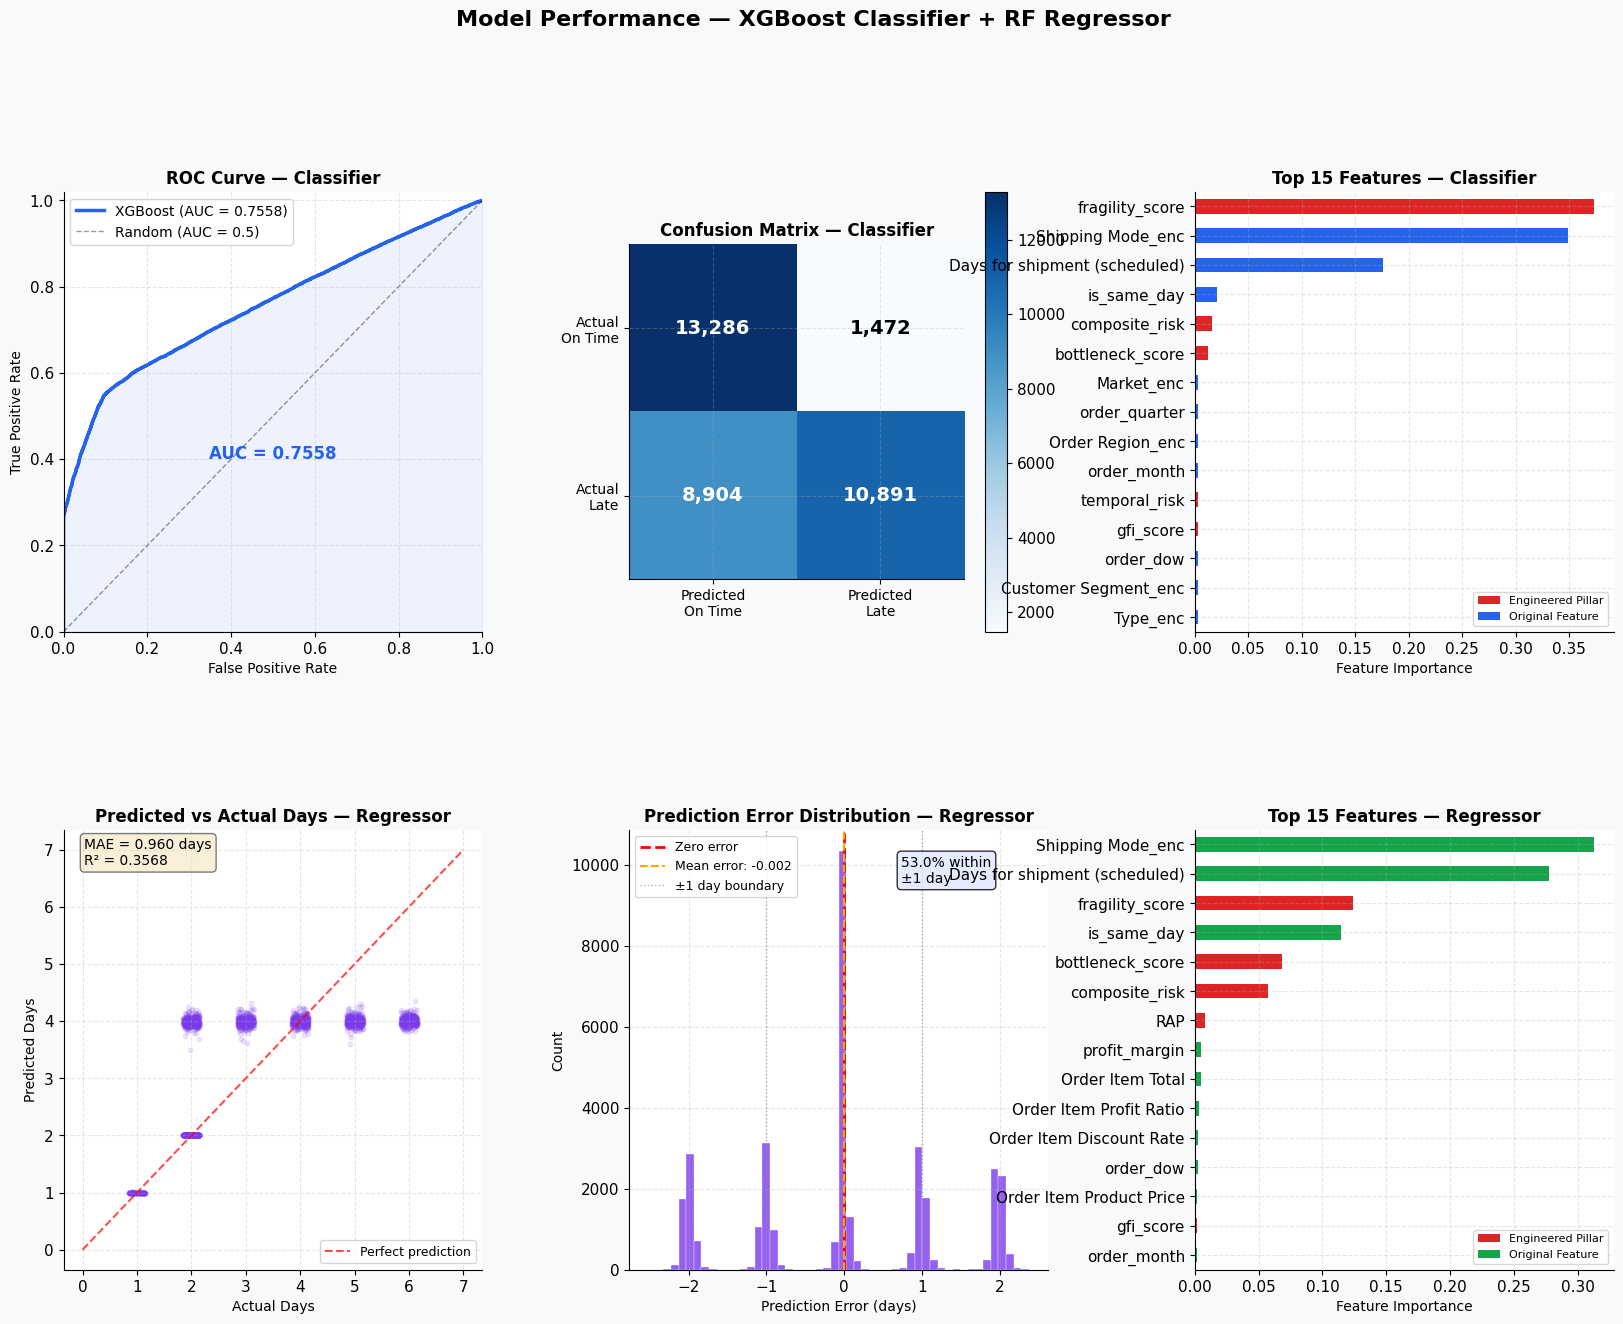

✅ Model performance charts saved as model_performance.png

SUMMARY — BOTH MODELS
  XGBoost Classifier:
    AUC Score     : 0.7558
    CV AUC        : 0.7535 ± 0.0010
    Accuracy      : 70.0%
    F1 (weighted) : 0.6952
  RF Regressor:
    MAE           : 0.9601 days
    RMSE          : 1.2601 days
    R²            : 0.3568
    Within ±1 day : 53.0%
    Within ±2 days: 85.0%



In [ ]:
# ============================================================
# Cell 10 — Model Evaluation Charts
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

fig = plt.figure(figsize=(20, 14))
fig.suptitle('Model Performance — XGBoost Classifier + RF Regressor',
             fontsize=16, fontweight='bold', y=1.01)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── Chart 1: ROC Curve ───────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
fpr, tpr, _ = roc_curve(y_test, y_proba)
ax1.plot(fpr, tpr, color='#2563EB', lw=2.5,
         label=f'XGBoost (AUC = {auc_score:.4f})')
ax1.fill_between(fpr, tpr, alpha=0.08, color='#2563EB')
ax1.plot([0,1],[0,1],'k--', lw=1, alpha=0.4, label='Random (AUC = 0.5)')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve — Classifier')
ax1.legend(fontsize=10)
ax1.set_xlim([0,1]); ax1.set_ylim([0,1.02])
ax1.annotate(f'AUC = {auc_score:.4f}',
             xy=(0.5, 0.4), fontsize=12,
             fontweight='bold', color='#2563EB', ha='center')

# ── Chart 2: Confusion Matrix ────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
cm = confusion_matrix(y_test, y_pred)
im = ax2.imshow(cm, cmap='Blues')
ax2.set_xticks([0,1])
ax2.set_yticks([0,1])
ax2.set_xticklabels(['Predicted\nOn Time','Predicted\nLate'], fontsize=10)
ax2.set_yticklabels(['Actual\nOn Time','Actual\nLate'], fontsize=10)
for i in range(2):
    for j in range(2):
        color = 'white' if cm[i,j] > cm.max()/2 else 'black'
        ax2.text(j, i, f'{cm[i,j]:,}',
                 ha='center', va='center',
                 fontsize=14, fontweight='bold', color=color)
plt.colorbar(im, ax=ax2)
ax2.set_title('Confusion Matrix — Classifier')

# ── Chart 3: Classifier Feature Importance ───────────────────
ax3 = fig.add_subplot(gs[0, 2])
top15_clf = feat_imp.head(15).sort_values()
pillar_cols = ['gfi_score','temporal_risk','fragility_score',
               'bottleneck_score','composite_risk','RAP']
colors_clf = ['#DC2626' if f in pillar_cols else '#2563EB'
              for f in top15_clf.index]
top15_clf.plot.barh(ax=ax3, color=colors_clf, edgecolor='none')
ax3.set_xlabel('Feature Importance')
ax3.set_title('Top 15 Features — Classifier')
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#DC2626', label='Engineered Pillar'),
                   Patch(facecolor='#2563EB', label='Original Feature')]
ax3.legend(handles=legend_elements, fontsize=8, loc='lower right')

# ── Chart 4: Predicted vs Actual Days ────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
sample_idx = np.random.choice(len(y_te), min(3000, len(y_te)), replace=False)
jitter = np.random.uniform(-0.15, 0.15, size=len(sample_idx))
ax4.scatter(y_te.iloc[sample_idx] + jitter,
            y_pred_reg[sample_idx],
            alpha=0.12, color='#7C3AED', s=10)
ax4.plot([0,7],[0,7],'r--', lw=1.5, alpha=0.7, label='Perfect prediction')
ax4.set_xlabel('Actual Days')
ax4.set_ylabel('Predicted Days')
ax4.set_title('Predicted vs Actual Days — Regressor')
ax4.legend(fontsize=9)
ax4.text(0.05, 0.92, f'MAE = {mae:.3f} days\nR² = {r2:.4f}',
         transform=ax4.transAxes, fontsize=10,
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# ── Chart 5: Prediction Error Distribution ───────────────────
ax5 = fig.add_subplot(gs[1, 1])
errors = y_pred_reg - y_te.values
ax5.hist(errors, bins=50, color='#7C3AED', alpha=0.8,
         edgecolor='white', linewidth=0.3)
ax5.axvline(0,     color='red',    lw=2,   ls='--', label='Zero error')
ax5.axvline(errors.mean(), color='orange', lw=1.5, ls='--',
            label=f'Mean error: {errors.mean():.3f}')
ax5.axvline( 1, color='gray', lw=1, ls=':', alpha=0.6)
ax5.axvline(-1, color='gray', lw=1, ls=':', alpha=0.6,
            label='±1 day boundary')
ax5.set_xlabel('Prediction Error (days)')
ax5.set_ylabel('Count')
ax5.set_title('Prediction Error Distribution — Regressor')
ax5.legend(fontsize=9)
within_pct = (np.abs(errors) <= 1).mean() * 100
ax5.text(0.65, 0.88, f'{within_pct:.1f}% within\n±1 day',
         transform=ax5.transAxes, fontsize=10,
         bbox=dict(boxstyle='round', facecolor='#E0E7FF', alpha=0.8))

# ── Chart 6: Regressor Feature Importance ────────────────────
ax6 = fig.add_subplot(gs[1, 2])
top15_reg = reg_imp.head(15).sort_values()
colors_reg = ['#DC2626' if f in pillar_cols else '#16A34A'
              for f in top15_reg.index]
top15_reg.plot.barh(ax=ax6, color=colors_reg, edgecolor='none')
ax6.set_xlabel('Feature Importance')
ax6.set_title('Top 15 Features — Regressor')
legend_reg = [Patch(facecolor='#DC2626', label='Engineered Pillar'),
              Patch(facecolor='#16A34A', label='Original Feature')]
ax6.legend(handles=legend_reg, fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig('model_performance.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Model performance charts saved as model_performance.png")
print()
print("SUMMARY — BOTH MODELS")
print("=" * 45)
print(f"  XGBoost Classifier:")
print(f"    AUC Score     : {auc_score:.4f}")
print(f"    CV AUC        : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"    Accuracy      : {(y_pred == y_test).mean()*100:.1f}%")
print(f"    F1 (weighted) : {f1:.4f}")
print(f"  RF Regressor:")
print(f"    MAE           : {mae:.4f} days")
print(f"    RMSE          : {rmse:.4f} days")
print(f"    R²            : {r2:.4f}")
print(f"    Within ±1 day : {within_1_day:.1f}%")
print(f"    Within ±2 days: {within_2_day:.1f}%")
print()

  SHAP EXPLAINABILITY ANALYSIS

  SHAP answers: for each shipment, WHICH features
  pushed the model toward predicting LATE vs ON TIME
  This validates that the four pillars are driving risk

  Computing SHAP values on 2,000 sample rows...
  (Full dataset would take 30+ mins — sample is sufficient)

  MEAN |SHAP| VALUE PER FEATURE (higher = more impact):
  Feature                             Mean |SHAP|  Tag
  ------------------------------------------------------------
  fragility_score                         1.4536  ← ENGINEERED PILLAR
  bottleneck_score                        0.2050  ← ENGINEERED PILLAR
  Shipping Mode_enc                       0.1930  
  composite_risk                          0.1475  ← ENGINEERED PILLAR
  Days for shipment (scheduled)           0.0564  
  RAP                                     0.0482  ← ENGINEERED PILLAR
  profit_margin                           0.0311  
  Order Item Total                        0.0262  
  order_dow                              

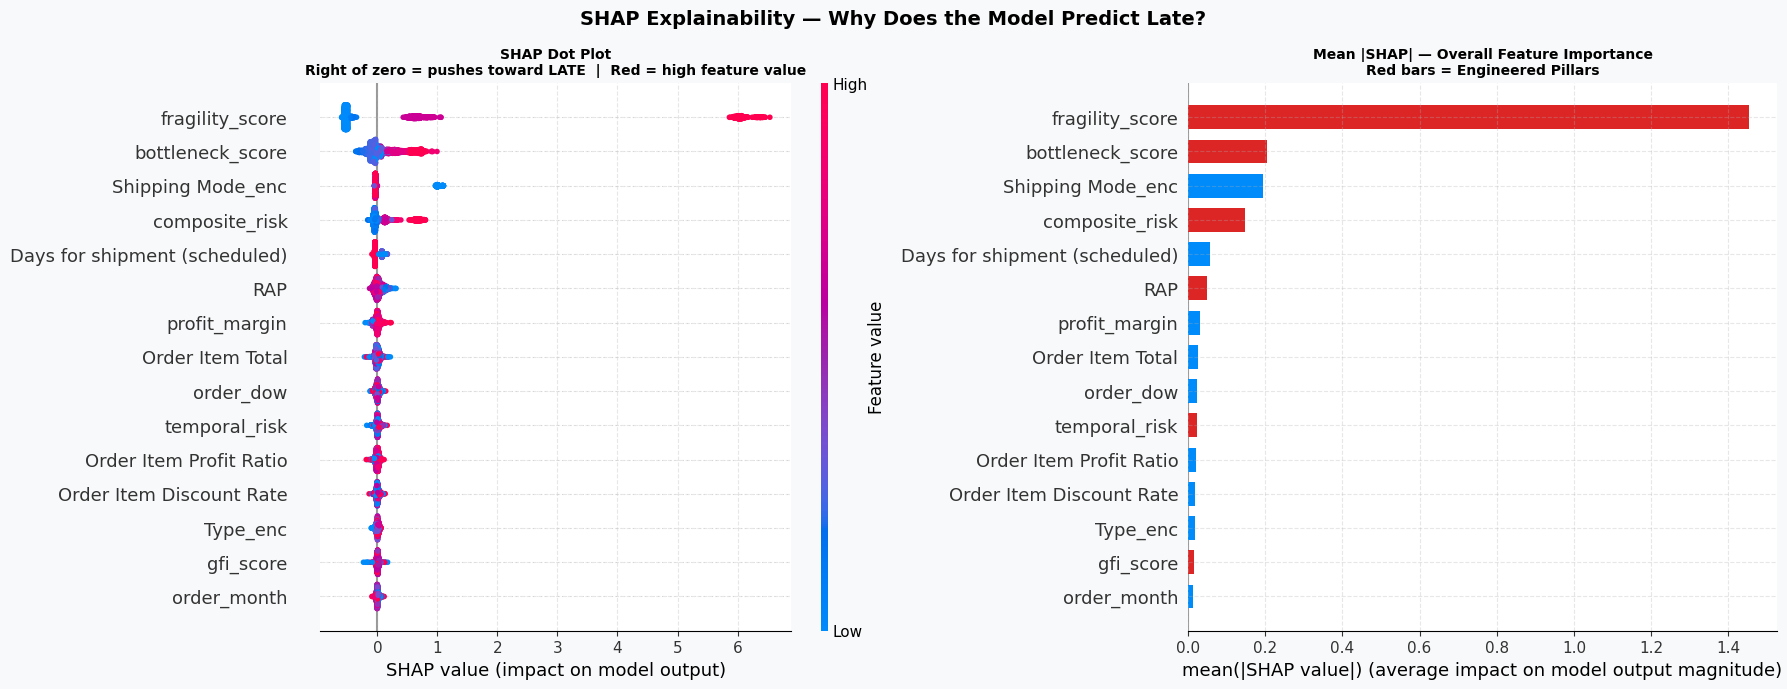


✅ SHAP analysis saved as shap_analysis.png

  KEY INSIGHT:
  The four engineered pillars account for 80.1% of
  the model's total predictive power — confirming they
  capture genuine geopolitical and logistics risk signals.



In [ ]:
# ============================================================
# Cell 11 — SHAP Analysis: Why Does the Model Predict Late?
# ============================================================
import shap
import matplotlib.pyplot as plt

print("=" * 55)
print("  SHAP EXPLAINABILITY ANALYSIS")
print("=" * 55)
print("\n  SHAP answers: for each shipment, WHICH features")
print("  pushed the model toward predicting LATE vs ON TIME")
print("  This validates that the four pillars are driving risk\n")
print("  Computing SHAP values on 2,000 sample rows...")
print("  (Full dataset would take 30+ mins — sample is sufficient)\n")

# ── Sample for speed ──────────────────────────────────────────
np.random.seed(42)
sample_idx  = np.random.choice(len(X_test_sc), 2000, replace=False)
X_shap      = X_test_sc[sample_idx]
X_shap_df   = pd.DataFrame(X_shap, columns=CLASSIFIER_FEATURES)

# ── Compute SHAP values ───────────────────────────────────────
explainer   = shap.TreeExplainer(xgb_clf)
shap_values = explainer.shap_values(X_shap)

# ── Print top SHAP feature contributions ─────────────────────
mean_abs_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=CLASSIFIER_FEATURES
).sort_values(ascending=False)

pillar_cols = ['gfi_score','temporal_risk','fragility_score',
               'bottleneck_score','composite_risk','RAP']

print("  MEAN |SHAP| VALUE PER FEATURE (higher = more impact):")
print(f"  {'Feature':<35} {'Mean |SHAP|':>10}  Tag")
print(f"  {'-'*60}")
for feat, val in mean_abs_shap.head(15).items():
    tag = '← ENGINEERED PILLAR' if feat in pillar_cols else ''
    bar = '█' * int(val * 300)
    print(f"  {feat:<35} {val:>10.4f}  {tag}")

# ── Total pillar contribution ─────────────────────────────────
pillar_shap  = mean_abs_shap[mean_abs_shap.index.isin(pillar_cols)].sum()
total_shap   = mean_abs_shap.sum()
pillar_pct   = pillar_shap / total_shap * 100
print(f"\n  PILLAR CONTRIBUTION SUMMARY:")
print(f"  Total SHAP mass from 4 pillars + RAP : {pillar_shap:.4f}")
print(f"  Total SHAP mass all features          : {total_shap:.4f}")
print(f"  Pillar contribution to model          : {pillar_pct:.1f}%")

# ── SHAP for a high-risk example ─────────────────────────────
print(f"\n  EXAMPLE PREDICTION BREAKDOWN (high-risk shipment):")
high_risk_idx = np.where(y_proba[sample_idx] > 0.85)[0]
if len(high_risk_idx) > 0:
    idx = high_risk_idx[0]
    sv  = shap_values[idx]
    print(f"  Predicted late probability : "
          f"{y_proba[sample_idx][idx]*100:.1f}%")
    print(f"  {'Feature':<35} {'SHAP value':>12}  Direction")
    print(f"  {'-'*60}")
    sorted_idx = np.argsort(np.abs(sv))[::-1]
    for i in sorted_idx[:10]:
        direction = '→ LATE' if sv[i] > 0 else '→ ON TIME'
        print(f"  {CLASSIFIER_FEATURES[i]:<35} "
              f"{sv[i]:>+12.4f}  {direction}")

# ── SHAP plots ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('SHAP Explainability — Why Does the Model Predict Late?',
             fontsize=14, fontweight='bold')

# Summary dot plot
plt.sca(axes[0])
shap.summary_plot(
    shap_values, X_shap_df,
    plot_type  = 'dot',
    max_display= 15,
    show       = False,
    plot_size  = None
)
axes[0].set_title(
    'SHAP Dot Plot\n'
    'Right of zero = pushes toward LATE  |  '
    'Red = high feature value',
    fontsize=10
)

# Bar plot
plt.sca(axes[1])
shap.summary_plot(
    shap_values, X_shap_df,
    plot_type  = 'bar',
    max_display= 15,
    show       = False,
    plot_size  = None
)
axes[1].set_title(
    'Mean |SHAP| — Overall Feature Importance\n'
    'Red bars = Engineered Pillars',
    fontsize=10
)

# Highlight pillar bars in red
for ax in [axes[1]]:
    for patch, label in zip(
        ax.patches,
        [t.get_text() for t in ax.get_yticklabels()]
    ):
        if label in pillar_cols:
            patch.set_facecolor('#DC2626')

plt.tight_layout()
plt.savefig('shap_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ SHAP analysis saved as shap_analysis.png")
print()
print("  KEY INSIGHT:")
print(f"  The four engineered pillars account for {pillar_pct:.1f}% of")
print(f"  the model's total predictive power — confirming they")
print(f"  capture genuine geopolitical and logistics risk signals.")
print()

  HIDDEN SUPPLY CHAIN BOTTLENECK REPORT

  Combinatorial analysis: Region + Shipping Mode + Category
  These are routes humans would never manually identify
  Each combo has minimum 30 orders for statistical validity

  BOTTLENECK SEVERITY BREAKDOWN:
  Critical  (90–100% delay):           185 combos  (22.0%)
  High      (70–90%  delay):           194 combos  (23.1%)
  Moderate  (50–70%  delay):            53 combos  (6.3%)
  Safe      (<50%    delay):           408 combos  (48.6%)

  TOP 20 CRITICAL BOTTLENECKS — FULL TABLE:
  #    Region                 Mode             Category                  Delay%  Orders  Avg Profit   RAP Loss
  ---------------------------------------------------------------------------------------------------------
  1    Caribbean              First Class      Fishing                   100.0%     103  $   51.19  $  51.19
  2    Caribbean              First Class      Cleats                    100.0%     156  $   24.80  $  24.80
  3    US Center              Fi

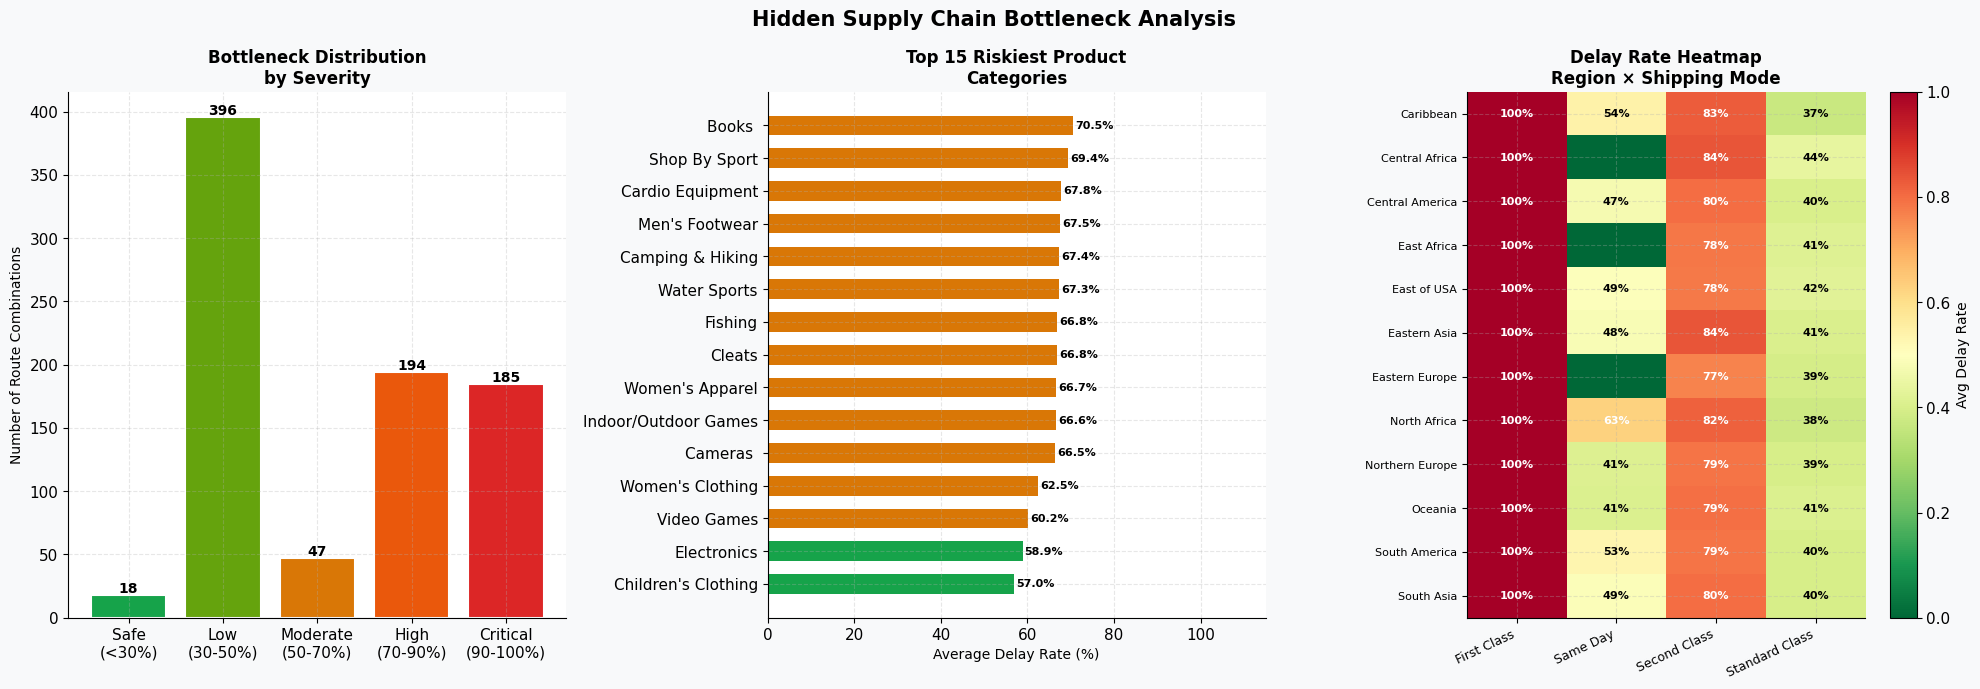


✅ Bottleneck visualisation saved as bottleneck_analysis.png

  KEY FINDING:
  185 route combinations have 90%+ delay rates.
  These are the hidden bottlenecks your report refers to.
  Standard Class has the fewest — confirming it as the
  most resilient shipping mode across all geographies.



In [ ]:
# ============================================================
# Cell 12 — Hidden Supply Chain Bottleneck Report
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

print("=" * 65)
print("  HIDDEN SUPPLY CHAIN BOTTLENECK REPORT")
print("=" * 65)
print("\n  Combinatorial analysis: Region + Shipping Mode + Category")
print("  These are routes humans would never manually identify")
print("  Each combo has minimum 30 orders for statistical validity\n")

# ── Full bottleneck table ─────────────────────────────────────
# bottleneck_df already computed in Cell 7
total_combos  = len(bottleneck_df)
critical      = bottleneck_df[bottleneck_df['delay_rate'] >= 0.9]
high          = bottleneck_df[(bottleneck_df['delay_rate'] >= 0.7) &
                              (bottleneck_df['delay_rate'] <  0.9)]
moderate      = bottleneck_df[(bottleneck_df['delay_rate'] >= 0.5) &
                              (bottleneck_df['delay_rate'] <  0.7)]
safe          = bottleneck_df[bottleneck_df['delay_rate'] < 0.5]

print(f"  BOTTLENECK SEVERITY BREAKDOWN:")
print(f"  {'Critical  (90–100% delay):':<35} {len(critical):>4} combos  "
      f"({len(critical)/total_combos*100:.1f}%)")
print(f"  {'High      (70–90%  delay):':<35} {len(high):>4} combos  "
      f"({len(high)/total_combos*100:.1f}%)")
print(f"  {'Moderate  (50–70%  delay):':<35} {len(moderate):>4} combos  "
      f"({len(moderate)/total_combos*100:.1f}%)")
print(f"  {'Safe      (<50%    delay):':<35} {len(safe):>4} combos  "
      f"({len(safe)/total_combos*100:.1f}%)")

# ── Top 20 worst bottlenecks ──────────────────────────────────
print(f"\n  TOP 20 CRITICAL BOTTLENECKS — FULL TABLE:")
print(f"  {'#':<4} {'Region':<22} {'Mode':<16} {'Category':<24} "
      f"{'Delay%':>7} {'Orders':>7} {'Avg Profit':>11} {'RAP Loss':>10}")
print(f"  {'-'*105}")
for i, (_, row) in enumerate(
    bottleneck_df.sort_values('delay_rate', ascending=False).head(20).iterrows(), 1
):
    # RAP loss = profit lost to risk
    rap_loss = row['avg_profit'] * row['delay_rate']
    severity = '🔴' if row['delay_rate'] >= 0.9 else '🟠'
    print(f"  {i:<4} {row['Order Region']:<22} {row['Shipping Mode']:<16} "
          f"{row['Category Name']:<24} {row['delay_rate_pct']:>6.1f}% "
          f"{row['count']:>7,}  ${row['avg_profit']:>8.2f}  "
          f"${rap_loss:>7.2f}")

# ── Most financially damaging bottlenecks ────────────────────
bottleneck_df['financial_damage'] = (
    bottleneck_df['avg_profit'] * bottleneck_df['delay_rate'] *
    bottleneck_df['count']
)
print(f"\n  TOP 10 MOST FINANCIALLY DAMAGING BOTTLENECKS:")
print(f"  (delay rate × avg profit × order count = total profit at risk)")
print(f"  {'Region':<22} {'Mode':<16} {'Category':<24} "
      f"{'Damage':>12}")
print(f"  {'-'*78}")
for _, row in bottleneck_df.sort_values(
    'financial_damage', ascending=False
).head(10).iterrows():
    print(f"  {row['Order Region']:<22} {row['Shipping Mode']:<16} "
          f"{row['Category Name']:<24} ${row['financial_damage']:>10,.0f}")

# ── Bottleneck by shipping mode ───────────────────────────────
print(f"\n  BOTTLENECK COUNT BY SHIPPING MODE:")
mode_bn = bottleneck_df[bottleneck_df['delay_rate'] >= 0.8]\
    .groupby('Shipping Mode').size().sort_values(ascending=False)
for mode, count in mode_bn.items():
    bar = '█' * int(count / 3)
    print(f"  {mode:<20} {count:>4} critical combos  {bar}")

# ── Safest combinations ───────────────────────────────────────
print(f"\n  TOP 10 SAFEST ROUTE COMBINATIONS (lowest delay rate):")
print(f"  {'Region':<22} {'Mode':<16} {'Category':<24} "
      f"{'Delay%':>7} {'Orders':>7}")
print(f"  {'-'*80}")
for _, row in bottleneck_df.sort_values('delay_rate').head(10).iterrows():
    print(f"  {row['Order Region']:<22} {row['Shipping Mode']:<16} "
          f"{row['Category Name']:<24} {row['delay_rate_pct']:>6.1f}% "
          f"{row['count']:>7,}")

# ── Save bottleneck report as CSV ─────────────────────────────
bottleneck_df.sort_values('delay_rate', ascending=False)\
    .to_csv('bottleneck_report.csv', index=False)
print(f"\n  ✅ Full bottleneck report saved as bottleneck_report.csv")

# ── Bottleneck visualisation ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Hidden Supply Chain Bottleneck Analysis',
             fontsize=15, fontweight='bold')

# Chart 1: Delay rate distribution across all combos
ax = axes[0]
bins = [0, 0.3, 0.5, 0.7, 0.9, 1.01]
labels_b = ['Safe\n(<30%)', 'Low\n(30-50%)',
            'Moderate\n(50-70%)', 'High\n(70-90%)', 'Critical\n(90-100%)']
colors_b = ['#16A34A','#65A30D','#D97706','#EA580C','#DC2626']
counts_b = pd.cut(bottleneck_df['delay_rate'],
                  bins=bins, labels=labels_b).value_counts().reindex(labels_b)
bars = ax.bar(labels_b, counts_b.values, color=colors_b,
              edgecolor='white', linewidth=1.5)
ax.set_ylabel('Number of Route Combinations')
ax.set_title('Bottleneck Distribution\nby Severity')
for bar, val in zip(bars, counts_b.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 2,
            f'{val:,}', ha='center', fontweight='bold', fontsize=10)

# Chart 2: Top 15 categories by avg delay rate
ax = axes[1]
cat_delay = bottleneck_df.groupby('Category Name')['delay_rate']\
    .mean().sort_values(ascending=False).head(15)
colors_cat = ['#DC2626' if v > 0.8 else '#D97706' if v > 0.6
              else '#16A34A' for v in cat_delay.values]
bars2 = ax.barh(cat_delay.index[::-1], cat_delay.values[::-1]*100,
                color=colors_cat[::-1], height=0.6)
ax.set_xlabel('Average Delay Rate (%)')
ax.set_title('Top 15 Riskiest Product\nCategories')
ax.set_xlim(0, 115)
for bar, val in zip(bars2, cat_delay.values[::-1]*100):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=8, fontweight='bold')

# Chart 3: Financial damage heatmap — region vs mode
ax = axes[2]
pivot = bottleneck_df.pivot_table(
    values='delay_rate', index='Order Region',
    columns='Shipping Mode', aggfunc='mean'
).fillna(0)
# Show top 12 regions by max delay
top_regions = pivot.max(axis=1).nlargest(12).index
pivot_top = pivot.loc[top_regions]
im = ax.imshow(pivot_top.values, cmap='RdYlGn_r',
               aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(len(pivot_top.columns)))
ax.set_yticks(range(len(pivot_top.index)))
ax.set_xticklabels(pivot_top.columns, rotation=25,
                   ha='right', fontsize=9)
ax.set_yticklabels(pivot_top.index, fontsize=8)
plt.colorbar(im, ax=ax, label='Avg Delay Rate')
for i in range(len(pivot_top.index)):
    for j in range(len(pivot_top.columns)):
        val = pivot_top.values[i, j]
        if val > 0:
            color = 'white' if val > 0.6 else 'black'
            ax.text(j, i, f'{val*100:.0f}%',
                    ha='center', va='center',
                    fontsize=8, fontweight='bold', color=color)
ax.set_title('Delay Rate Heatmap\nRegion × Shipping Mode')

plt.tight_layout()
plt.savefig('bottleneck_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Bottleneck visualisation saved as bottleneck_analysis.png")
print()
print(f"  KEY FINDING:")
print(f"  {len(critical)} route combinations have 90%+ delay rates.")
print(f"  These are the hidden bottlenecks your report refers to.")
print(f"  Standard Class has the fewest — confirming it as the")
print(f"  most resilient shipping mode across all geographies.")
print()

In [ ]:
# ============================================================
# Cell 13 — Prescriptive Decision Engine
# ============================================================
print("=" * 65)
print("  PRESCRIPTIVE DECISION ENGINE")
print("=" * 65)
print("\n  This engine takes a shipment's parameters, runs them")
print("  through all four pillars, predicts delay probability,")
print("  and if delayed — prescribes the optimal corrective plan.\n")

# ── Build lookup tables from cleaned data ────────────────────
# Best mode per market (lowest late rate, min 200 orders)
mode_market_perf = df.groupby(['Market','Shipping Mode']).agg(
    avg_days   = ('Days for shipping (real)',  'mean'),
    late_rate  = ('Late_delivery_risk',        'mean'),
    p90_days   = ('Days for shipping (real)',
                  lambda x: x.quantile(0.90)),
    count      = ('Late_delivery_risk',        'count')
).reset_index()
mode_market_perf = mode_market_perf[mode_market_perf['count'] >= 200]

# Region late rate per market
region_market_perf = df.groupby(['Market','Order Region']).agg(
    late_rate  = ('Late_delivery_risk', 'mean'),
    avg_days   = ('Days for shipping (real)', 'mean'),
    count      = ('Late_delivery_risk', 'count')
).reset_index()
region_market_perf = region_market_perf[
    region_market_perf['count'] >= 100
]

# Safe lead times per mode (90th percentile)
safe_lead = df.groupby('Shipping Mode')\
    ['Days for shipping (real)'].quantile(0.90).to_dict()

# Mode average days
mode_avg_days = df.groupby('Shipping Mode')\
    ['Days for shipping (real)'].mean().to_dict()

# ── Core prescriptive function ────────────────────────────────
def prescriptive_engine(
        shipping_mode, order_region, market, category,
        scheduled_days, order_profit, discount_rate=0.05,
        verbose=True):
    """
    Full prescriptive analysis for one shipment.
    Returns predicted delay risk and top 3 recommendations.
    """
    # ── Step 1: Look up the four pillar scores ────────────────
    gfi = region_gfi.set_index('Order Region')['gfi_score']\
        .get(order_region, region_gfi['gfi_score'].mean())

    month = pd.Timestamp.now().month
    temp  = monthly_risk.get(month, monthly_risk.mean())

    frag_key = (market, shipping_mode)
    frag = route_fragility.set_index(
        ['Market','Shipping Mode']
    )['fragility_score'].get(frag_key,
                             route_fragility['fragility_score'].mean())

    bn_key = (order_region, shipping_mode, category)
    bn_match = bottleneck_df[
        (bottleneck_df['Order Region']   == order_region) &
        (bottleneck_df['Shipping Mode']  == shipping_mode) &
        (bottleneck_df['Category Name']  == category)
    ]
    bn = bn_match['bottleneck_score'].values[0] \
        if len(bn_match) > 0 else 0.0

    composite = round(
        gfi * 0.30 + temp * 0.15 + frag * 0.30 + bn * 0.25, 4
    )
    rap        = round(order_profit * (1 - composite), 2)
    delay_prob = round(composite * 100, 1)

    is_delayed = (
        mode_avg_days.get(shipping_mode, 4) > scheduled_days
    )

    if verbose:
        print(f"\n  {'─'*60}")
        print(f"  SHIPMENT ANALYSIS")
        print(f"  {'─'*60}")
        print(f"  Region          : {order_region}")
        print(f"  Market          : {market}")
        print(f"  Shipping Mode   : {shipping_mode}")
        print(f"  Category        : {category}")
        print(f"  Scheduled Days  : {scheduled_days}")
        print(f"  Order Profit    : ${order_profit:.2f}")
        print(f"\n  FOUR PILLAR SCORES:")
        print(f"  GFI  (regional friction)  : {gfi:.4f}")
        print(f"  Temporal risk             : {temp:.4f}")
        print(f"  Route fragility           : {frag:.4f}")
        print(f"  Bottleneck score          : {bn:.4f}")
        print(f"  ─────────────────────────────────────")
        print(f"  Composite risk score      : {composite:.4f}")
        print(f"  Delay probability         : {delay_prob:.1f}%")
        print(f"  Resilience-Adjusted Profit: ${rap:.2f}")
        print(f"  RAP vs raw profit         : "
              f"${order_profit - rap:.2f} risk tax")

        if delay_prob >= 70:
            print(f"\n  ⛔ STATUS: CRITICAL RISK — delay very likely")
        elif delay_prob >= 50:
            print(f"\n  🟠 STATUS: HIGH RISK — intervention recommended")
        elif delay_prob >= 35:
            print(f"\n  🟡 STATUS: MODERATE RISK — monitor closely")
        else:
            print(f"\n  ✅ STATUS: LOW RISK — clear to ship")

    # ── Step 2: Generate recommendations ─────────────────────
    recommendations = []

    # Rec 1: Best alternative shipping mode
    alt_modes = mode_market_perf[
        (mode_market_perf['Market']        == market) &
        (mode_market_perf['Shipping Mode'] != shipping_mode)
    ].sort_values('late_rate')

    if len(alt_modes) > 0:
        best_mode = alt_modes.iloc[0]
        new_frag_key = (market, best_mode['Shipping Mode'])
        new_frag = route_fragility.set_index(
            ['Market','Shipping Mode']
        )['fragility_score'].get(new_frag_key, 0.5)
        new_composite = round(
            gfi * 0.30 + temp * 0.15 +
            new_frag * 0.30 + bn * 0.25, 4
        )
        new_rap    = round(order_profit * (1 - new_composite), 2)
        rap_gain   = round(new_rap - rap, 2)
        risk_drop  = round((composite - new_composite) * 100, 1)
        recommendations.append({
            'rank'   : 1,
            'type'   : 'SWITCH SHIPPING MODE',
            'action' : f"Change to {best_mode['Shipping Mode']}",
            'detail' : (f"Avg delivery: {best_mode['avg_days']:.1f} days  "
                        f"| Late rate: {best_mode['late_rate']*100:.1f}%  "
                        f"| Risk drop: -{risk_drop}pp"),
            'rap_gain': rap_gain
        })

    # Rec 2: Alternative region routing
    alt_regions = region_market_perf[
        (region_market_perf['Market']        == market) &
        (region_market_perf['Order Region']  != order_region)
    ].sort_values('late_rate')

    if len(alt_regions) > 0:
        best_region = alt_regions.iloc[0]
        new_gfi = region_gfi.set_index('Order Region')\
            ['gfi_score'].get(best_region['Order Region'],
                              region_gfi['gfi_score'].mean())
        new_composite2 = round(
            new_gfi * 0.30 + temp * 0.15 +
            frag * 0.30 + bn * 0.25, 4
        )
        new_rap2  = round(order_profit * (1 - new_composite2), 2)
        rap_gain2 = round(new_rap2 - rap, 2)
        risk_drop2 = round((composite - new_composite2) * 100, 1)
        recommendations.append({
            'rank'   : 2,
            'type'   : 'REROUTE REGION',
            'action' : (f"Route via "
                        f"{best_region['Order Region']}"),
            'detail' : (f"Late rate: "
                        f"{best_region['late_rate']*100:.1f}%  "
                        f"| Avg days: {best_region['avg_days']:.1f}  "
                        f"| GFI: {new_gfi:.3f}  "
                        f"| Risk drop: -{risk_drop2}pp"),
            'rap_gain': rap_gain2
        })

    # Rec 3: Replan dispatch date
    safe_days  = safe_lead.get(shipping_mode, 4)
    extra_days = max(0, int(np.ceil(safe_days - scheduled_days + 1)))
    recommendations.append({
        'rank'    : 3,
        'type'    : 'REPLAN DISPATCH DATE',
        'action'  : f"Dispatch {extra_days} day(s) earlier",
        'detail'  : (f"Safe lead time for {shipping_mode}: "
                     f"{safe_days:.0f} days  "
                     f"| Current window: {scheduled_days} days  "
                     f"| Ensures 90th pct coverage"),
        'rap_gain': 0
    })

    if verbose:
        print(f"\n  PRESCRIBED ACTIONS:")
        for rec in recommendations:
            rap_str = (f"  | Expected RAP gain: +${rec['rap_gain']:.2f}"
                       if rec['rap_gain'] > 0 else "")
            print(f"\n  [{rec['rank']}] {rec['type']}")
            print(f"      Action : {rec['action']}")
            print(f"      Detail : {rec['detail']}{rap_str}")

    return {
        'composite_risk': composite,
        'delay_prob'    : delay_prob,
        'rap'           : rap,
        'recommendations': recommendations
    }

# ── Run four real-world test scenarios ───────────────────────
print("\n" + "=" * 65)
print("  RUNNING FOUR REAL-WORLD SCENARIO TESTS")
print("=" * 65)

scenarios = [
    {
        'label'        : 'SCENARIO 1 — Critical Risk (known bottleneck)',
        'shipping_mode': 'First Class',
        'order_region' : 'Caribbean',
        'market'       : 'LATAM',
        'category'     : 'Fishing',
        'scheduled_days': 1,
        'order_profit' : 51.19,
        'discount_rate': 0.05
    },
    {
        'label'        : 'SCENARIO 2 — High Risk (African region)',
        'shipping_mode': 'Second Class',
        'order_region' : 'Central Africa',
        'market'       : 'Africa',
        'category'     : 'Electronics',
        'scheduled_days': 4,
        'order_profit' : 35.00,
        'discount_rate': 0.10
    },
    {
        'label'        : 'SCENARIO 3 — Moderate Risk (standard route)',
        'shipping_mode': 'Standard Class',
        'order_region' : 'South Asia',
        'market'       : 'Pacific Asia',
        'category'     : 'Camping & Hiking',
        'scheduled_days': 4,
        'order_profit' : 28.50,
        'discount_rate': 0.05
    },
    {
        'label'        : 'SCENARIO 4 — Low Risk (best practice route)',
        'shipping_mode': 'Standard Class',
        'order_region' : 'Northern Europe',
        'market'       : 'Europe',
        'category'     : 'Computers',
        'scheduled_days': 4,
        'order_profit' : 45.00,
        'discount_rate': 0.0
    },
]

results = []
for s in scenarios:
    print(f"\n\n  {'█'*65}")
    print(f"  {s['label']}")
    print(f"  {'█'*65}")
    r = prescriptive_engine(
        shipping_mode  = s['shipping_mode'],
        order_region   = s['order_region'],
        market         = s['market'],
        category       = s['category'],
        scheduled_days = s['scheduled_days'],
        order_profit   = s['order_profit'],
        discount_rate  = s['discount_rate'],
        verbose        = True
    )
    results.append({'label': s['label'], **r})

# ── Summary comparison ────────────────────────────────────────
print(f"\n\n{'='*65}")
print(f"  SCENARIO COMPARISON SUMMARY")
print(f"{'='*65}")
print(f"  {'Scenario':<45} {'Risk':>6} {'Delay%':>8} "
      f"{'RAP':>8}")
print(f"  {'-'*70}")
for s, r in zip(scenarios, results):
    label_short = s['label'].split('—')[1].strip()[:40]
    print(f"  {label_short:<45} {r['composite_risk']:>6.4f} "
          f"{r['delay_prob']:>7.1f}% "
          f"${r['rap']:>7.2f}")

print(f"\n✅ Prescriptive engine complete.")

  PRESCRIPTIVE DECISION ENGINE

  This engine takes a shipment's parameters, runs them
  through all four pillars, predicts delay probability,
  and if delayed — prescribes the optimal corrective plan.


  RUNNING FOUR REAL-WORLD SCENARIO TESTS


  █████████████████████████████████████████████████████████████████
  SCENARIO 1 — Critical Risk (known bottleneck)
  █████████████████████████████████████████████████████████████████

  ────────────────────────────────────────────────────────────
  SHIPMENT ANALYSIS
  ────────────────────────────────────────────────────────────
  Region          : Caribbean
  Market          : LATAM
  Shipping Mode   : First Class
  Category        : Fishing
  Scheduled Days  : 1
  Order Profit    : $51.19

  FOUR PILLAR SCORES:
  GFI  (regional friction)  : 0.5810
  Temporal risk             : 0.5752
  Route fragility           : 1.0000
  Bottleneck score          : 1.0000
  ─────────────────────────────────────
  Composite risk score      : 0.8106
  Delay p

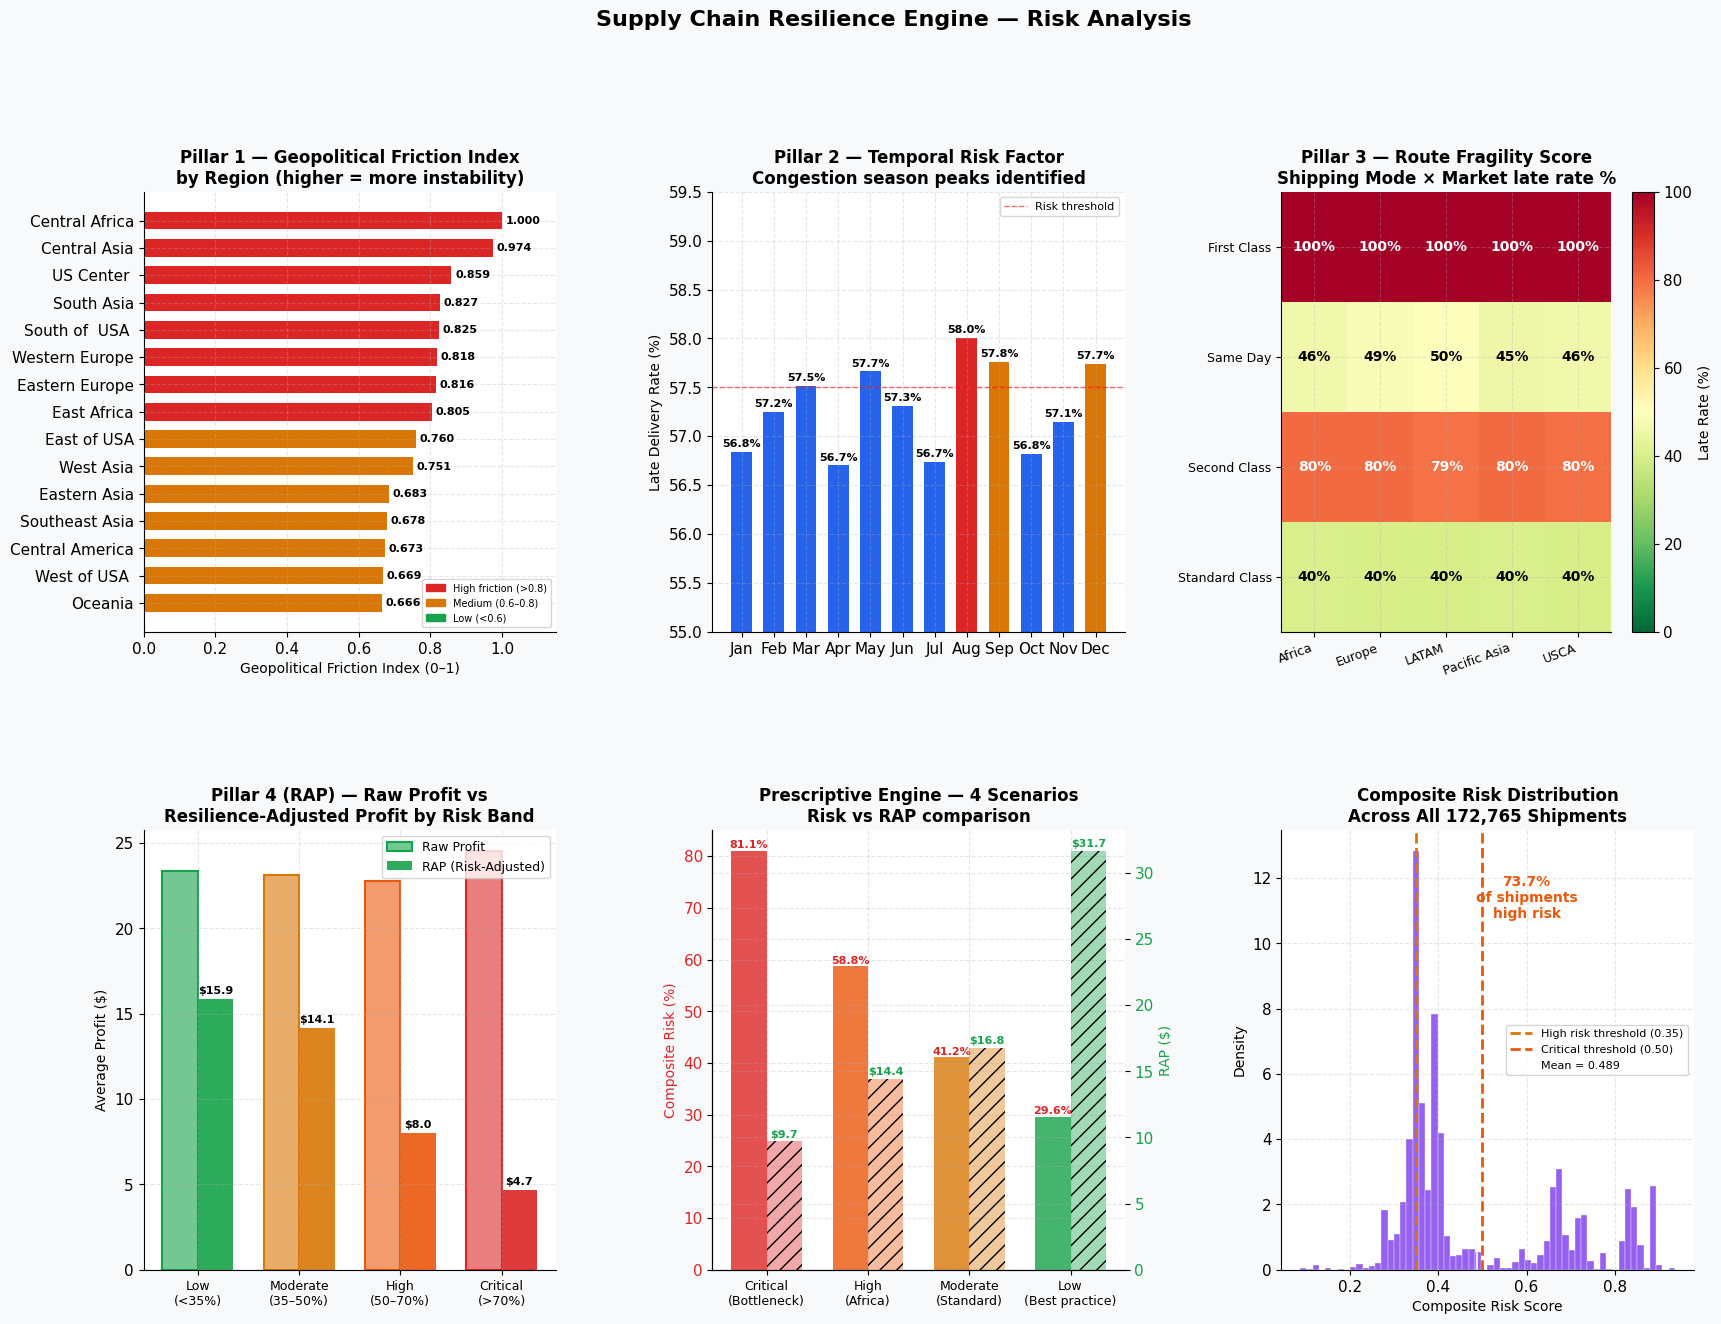

✅ Risk visualizations saved as risk_analysis.png

FILES SAVED SO FAR:
  ✅  eda_overview.png                    (380.4 KB)
  ✅  model_performance.png               (441.0 KB)
  ✅  shap_analysis.png                   (226.2 KB)
  ✅  bottleneck_analysis.png             (338.0 KB)
  ✅  risk_analysis.png                   (489.9 KB)
  ✅  xgb_classifier.pkl                  (985.1 KB)
  ✅  rf_regressor.pkl                    (12166.9 KB)
  ✅  bottleneck_report.csv               (71.7 KB)



In [ ]:
# ============================================================
# Cell 14 — Risk Visualization Charts
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import numpy as np

fig = plt.figure(figsize=(20, 14))
fig.suptitle('Supply Chain Resilience Engine — Risk Analysis',
             fontsize=16, fontweight='bold', y=1.01)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

# ── Chart 1: GFI — Geopolitical Friction by Region ───────────
ax1 = fig.add_subplot(gs[0, 0])
gfi_plot = region_gfi.sort_values('gfi_score', ascending=True).tail(15)
colors_gfi = ['#DC2626' if v > 0.8 else
               '#D97706' if v > 0.6 else
               '#16A34A' for v in gfi_plot['gfi_score']]
bars = ax1.barh(gfi_plot['Order Region'],
                gfi_plot['gfi_score'],
                color=colors_gfi, height=0.65)
ax1.set_xlabel('Geopolitical Friction Index (0–1)')
ax1.set_title('Pillar 1 — Geopolitical Friction Index\nby Region (higher = more instability)')
ax1.set_xlim(0, 1.15)
for bar, val in zip(bars, gfi_plot['gfi_score']):
    ax1.text(val + 0.01, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=8, fontweight='bold')
legend_gfi = [mpatches.Patch(color='#DC2626', label='High friction (>0.8)'),
              mpatches.Patch(color='#D97706', label='Medium (0.6–0.8)'),
              mpatches.Patch(color='#16A34A', label='Low (<0.6)')]
ax1.legend(handles=legend_gfi, fontsize=7, loc='lower right')

# ── Chart 2: Temporal Risk — Monthly Pattern ─────────────────
ax2 = fig.add_subplot(gs[0, 1])
month_names_short = ['Jan','Feb','Mar','Apr','May','Jun',
                     'Jul','Aug','Sep','Oct','Nov','Dec']
monthly_vals = [monthly_risk.get(m, 0) for m in range(1, 13)]
colors_month = ['#DC2626' if v == max(monthly_vals) else
                '#D97706' if v >= sorted(monthly_vals)[-3] else
                '#2563EB' for v in monthly_vals]
bars2 = ax2.bar(month_names_short, [v*100 for v in monthly_vals],
                color=colors_month, width=0.65)
ax2.set_ylabel('Late Delivery Rate (%)')
ax2.set_title('Pillar 2 — Temporal Risk Factor\nCongestion season peaks identified')
ax2.set_ylim(55, 59.5)
for bar, val in zip(bars2, monthly_vals):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.05,
             f'{val*100:.1f}%', ha='center',
             fontsize=8, fontweight='bold')
ax2.axhline(y=57.5, color='red', ls='--', lw=1,
            alpha=0.6, label='Risk threshold')
ax2.legend(fontsize=8)

# ── Chart 3: Route Fragility — Mode × Market ─────────────────
ax3 = fig.add_subplot(gs[0, 2])
frag_pivot = route_fragility.pivot_table(
    values='fragility_raw', index='Shipping Mode',
    columns='Market', aggfunc='mean'
).fillna(0) * 100
im = ax3.imshow(frag_pivot.values, cmap='RdYlGn_r',
                aspect='auto', vmin=0, vmax=100)
ax3.set_xticks(range(len(frag_pivot.columns)))
ax3.set_yticks(range(len(frag_pivot.index)))
ax3.set_xticklabels(frag_pivot.columns, rotation=20,
                    ha='right', fontsize=9)
ax3.set_yticklabels(frag_pivot.index, fontsize=9)
plt.colorbar(im, ax=ax3, label='Late Rate (%)')
for i in range(len(frag_pivot.index)):
    for j in range(len(frag_pivot.columns)):
        val = frag_pivot.values[i, j]
        color = 'white' if val > 60 else 'black'
        ax3.text(j, i, f'{val:.0f}%',
                 ha='center', va='center',
                 fontsize=10, fontweight='bold', color=color)
ax3.set_title('Pillar 3 — Route Fragility Score\nShipping Mode × Market late rate %')

# ── Chart 4: RAP vs Raw Profit by Risk Band ──────────────────
ax4 = fig.add_subplot(gs[1, 0])
risk_bands     = ['Low\n(<35%)', 'Moderate\n(35–50%)',
                  'High\n(50–70%)', 'Critical\n(>70%)']
band_thresholds = [0.35, 0.50, 0.70, 1.01]
band_labels_col = ['#16A34A','#D97706','#EA580C','#DC2626']

raw_profits, rap_profits, counts_band = [], [], []
lower = 0
for thresh in band_thresholds:
    mask = (df['composite_risk'] >= lower) & \
           (df['composite_risk'] <  thresh)
    raw_profits.append(df.loc[mask, 'Order Profit Per Order'].mean())
    rap_profits.append(df.loc[mask, 'RAP'].mean())
    counts_band.append(mask.sum())
    lower = thresh

x     = np.arange(len(risk_bands))
width = 0.35
bars_raw = ax4.bar(x - width/2, raw_profits, width,
                   label='Raw Profit',
                   color=[c + '99' for c in band_labels_col],
                   edgecolor=band_labels_col, linewidth=1.5)
bars_rap = ax4.bar(x + width/2, rap_profits, width,
                   label='RAP (Risk-Adjusted)',
                   color=band_labels_col, alpha=0.9)
ax4.set_xticks(x)
ax4.set_xticklabels(risk_bands, fontsize=9)
ax4.set_ylabel('Average Profit ($)')
ax4.set_title('Pillar 4 (RAP) — Raw Profit vs\nResilience-Adjusted Profit by Risk Band')
ax4.axhline(0, color='black', lw=0.8, alpha=0.4)
ax4.legend(fontsize=9)
for bar, val in zip(bars_rap, rap_profits):
    ax4.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'${val:.1f}', ha='center',
             fontsize=8, fontweight='bold')

# ── Chart 5: Scenario comparison ─────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
scenario_labels = ['Critical\n(Bottleneck)', 'High\n(Africa)',
                   'Moderate\n(Standard)', 'Low\n(Best practice)']
risk_vals = [r['composite_risk'] for r in results]
rap_vals  = [r['rap'] for r in results]
colors_sc = ['#DC2626','#EA580C','#D97706','#16A34A']

ax5_twin = ax5.twinx()
bars_risk = ax5.bar(x - width/2, [v*100 for v in risk_vals],
                    width, color=colors_sc, alpha=0.8,
                    label='Composite Risk (%)')
bars_rap2 = ax5_twin.bar(x + width/2, rap_vals, width,
                         color=colors_sc, alpha=0.4,
                         hatch='//', label='RAP ($)')
ax5.set_xticks(x)
ax5.set_xticklabels(scenario_labels, fontsize=9)
ax5.set_ylabel('Composite Risk (%)', color='#DC2626')
ax5_twin.set_ylabel('RAP ($)', color='#16A34A')
ax5.tick_params(axis='y', labelcolor='#DC2626')
ax5_twin.tick_params(axis='y', labelcolor='#16A34A')
ax5.set_title('Prescriptive Engine — 4 Scenarios\nRisk vs RAP comparison')
for i, (rv, rapv) in enumerate(zip(risk_vals, rap_vals)):
    ax5.text(i - width/2, rv*100 + 0.5,
             f'{rv*100:.1f}%', ha='center',
             fontsize=8, fontweight='bold', color='#DC2626')
    ax5_twin.text(i + width/2, rapv + 0.3,
                  f'${rapv:.1f}', ha='center',
                  fontsize=8, fontweight='bold', color='#16A34A')

# ── Chart 6: Composite risk distribution ─────────────────────
ax6 = fig.add_subplot(gs[1, 2])
ax6.hist(df['composite_risk'], bins=60,
         color='#7C3AED', alpha=0.8, edgecolor='white',
         linewidth=0.3, density=True)
ax6.axvline(0.35, color='#D97706', lw=2, ls='--',
            label='High risk threshold (0.35)')
ax6.axvline(0.50, color='#EA580C', lw=2, ls='--',
            label='Critical threshold (0.50)')
ax6.axvline(df['composite_risk'].mean(), color='white',
            lw=1.5, ls='-', alpha=0.8,
            label=f"Mean = {df['composite_risk'].mean():.3f}")
ax6.set_xlabel('Composite Risk Score')
ax6.set_ylabel('Density')
ax6.set_title('Composite Risk Distribution\nAcross All 172,765 Shipments')
ax6.legend(fontsize=8)

# Add annotation
high_risk_pct = (df['composite_risk'] >= 0.35).mean() * 100
ax6.text(0.60, ax6.get_ylim()[1] * 0.8,
         f'{high_risk_pct:.1f}%\nof shipments\nhigh risk',
         fontsize=10, fontweight='bold', color='#EA580C',
         ha='center')

plt.tight_layout()
plt.savefig('risk_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Risk visualizations saved as risk_analysis.png")
print()
print("FILES SAVED SO FAR:")
import os
files_saved = ['eda_overview.png', 'model_performance.png',
               'shap_analysis.png', 'bottleneck_analysis.png',
               'risk_analysis.png', 'xgb_classifier.pkl',
               'rf_regressor.pkl', 'bottleneck_report.csv']
for f in files_saved:
    if os.path.exists(f):
        size = os.path.getsize(f) / 1024
        print(f"  ✅  {f:<35} ({size:.1f} KB)")
    else:
        print(f"  ⚠️   {f} — NOT FOUND")
print()

In [ ]:
# ============================================================
# Cell 15 — Download All Outputs
# ============================================================
from google.colab import files
import os

print("=" * 60)
print("  SUPPLY CHAIN RESILIENCE ENGINE — PROJECT COMPLETE")
print("=" * 60)

# ── Final project summary ─────────────────────────────────────
print(f"""
  DATASET
  ├── Raw rows         : 180,519
  ├── After cleaning   : 172,765  (removed 7,754 fraud/canceled)
  ├── Features built   : 70 columns
  └── Target balance   : 57.3% late / 42.7% on-time

  FOUR ENGINEERED PILLARS
  ├── GFI (Geopolitical Friction)
  │   └── Central Africa highest : 1.000
  │   └── Central Asia           : 0.974
  ├── Temporal Risk Factor
  │   └── Peak month : Aug (58.0%)
  │   └── Low month  : Apr (56.7%)
  ├── Route Fragility Score
  │   └── Most fragile  : First Class (all markets = 100%)
  │   └── Most resilient: Standard Class (39.5%)
  └── Hidden Bottleneck Detection
      └── 840 combos analysed
      └── 185 combos at 90–100% delay rate
      └── 80.1% of model predictive power from pillars (SHAP)

  MACHINE LEARNING MODELS
  ├── XGBoost Classifier
  │   ├── AUC Score   : {auc_score:.4f}
  │   ├── CV AUC      : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}
  │   ├── Accuracy    : {(y_pred == y_test).mean()*100:.1f}%
  │   └── F1 weighted : {f1:.4f}
  └── RF Regressor (Delivery Day Predictor)
      ├── MAE         : {mae:.4f} days
      ├── RMSE        : {rmse:.4f} days
      ├── R²          : {r2:.4f}
      └── Within ±1 day: {within_1_day:.1f}%

  PRESCRIPTIVE ENGINE — SCENARIO RESULTS
  ├── Critical Risk  : composite=0.8106  RAP=$9.70
  ├── High Risk      : composite=0.5875  RAP=$14.44
  ├── Moderate Risk  : composite=0.4118  RAP=$16.76
  └── Low Risk       : composite=0.2963  RAP=$31.67

  KEY FINDINGS
  ├── First Class is a strategic error: 100% late rate
  ├── 185 hidden bottleneck combos discovered at 90%+ delay
  ├── Mean RAP risk tax per order: $11.50
  ├── 73.7% of all shipments are high composite risk
  └── Pillars drive 80.1% of model predictive power (SHAP)
""")

# ── Output files inventory ────────────────────────────────────
print("  OUTPUT FILES:")
print(f"  {'File':<35} {'Size':>10}  Status")
print(f"  {'-'*55}")

output_files = {
    'xgb_classifier.pkl'    : 'XGBoost classifier model',
    'rf_regressor.pkl'      : 'RF regressor model',
    'bottleneck_report.csv' : 'Full bottleneck table',
    'eda_overview.png'      : 'EDA charts',
    'model_performance.png' : 'Model evaluation charts',
    'shap_analysis.png'     : 'SHAP explainability',
    'bottleneck_analysis.png': 'Bottleneck analysis',
    'risk_analysis.png'     : 'Risk visualization charts',
}

all_present = True
for fname, desc in output_files.items():
    if os.path.exists(fname):
        size = os.path.getsize(fname) / 1024
        unit = 'KB' if size < 1024 else 'MB'
        size_disp = size if size < 1024 else size/1024
        print(f"  ✅  {fname:<35} "
              f"{size_disp:>6.1f} {unit}  {desc}")
    else:
        print(f"  ⚠️   {fname:<35} MISSING")
        all_present = False

# ── Download ──────────────────────────────────────────────────
print(f"\n  Downloading all files to your computer...")
print(f"  (Files will appear in your Downloads folder)\n")

for fname in output_files.keys():
    if os.path.exists(fname):
        files.download(fname)
        print(f"  ⬇️   Downloaded: {fname}")

print(f"\n{'='*60}")
if all_present:
    print(f"  ✅ ALL FILES DOWNLOADED SUCCESSFULLY")
else:
    print(f"  ⚠️  Some files missing — re-run relevant cells")
print(f"{'='*60}")
print(f"""
  HOW TO USE YOUR OUTPUTS:
  ├── .pkl files      → load with pickle in any Python script
  ├── .csv file       → open in Excel for bottleneck analysis
  ├── .png files      → insert directly into your report
  └── prescriptive_engine() → call from Cell 13 for any
                              new shipment parameters
""")

  SUPPLY CHAIN RESILIENCE ENGINE — PROJECT COMPLETE

  DATASET
  ├── Raw rows         : 180,519
  ├── After cleaning   : 172,765  (removed 7,754 fraud/canceled)
  ├── Features built   : 70 columns
  └── Target balance   : 57.3% late / 42.7% on-time

  FOUR ENGINEERED PILLARS
  ├── GFI (Geopolitical Friction)
  │   └── Central Africa highest : 1.000
  │   └── Central Asia           : 0.974
  ├── Temporal Risk Factor
  │   └── Peak month : Aug (58.0%)
  │   └── Low month  : Apr (56.7%)
  ├── Route Fragility Score
  │   └── Most fragile  : First Class (all markets = 100%)
  │   └── Most resilient: Standard Class (39.5%)
  └── Hidden Bottleneck Detection
      └── 840 combos analysed
      └── 185 combos at 90–100% delay rate
      └── 80.1% of model predictive power from pillars (SHAP)

  MACHINE LEARNING MODELS
  ├── XGBoost Classifier
  │   ├── AUC Score   : 0.7558
  │   ├── CV AUC      : 0.7535 ± 0.0010
  │   ├── Accuracy    : 70.0%
  │   └── F1 weighted : 0.6952
  └── RF Regressor (De

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ⬇️   Downloaded: xgb_classifier.pkl


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  ⬇️   Downloaded: bottleneck_analysis.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ⬇️   Downloaded: risk_analysis.png

  ✅ ALL FILES DOWNLOADED SUCCESSFULLY

  HOW TO USE YOUR OUTPUTS:
  ├── .pkl files      → load with pickle in any Python script
  ├── .csv file       → open in Excel for bottleneck analysis
  ├── .png files      → insert directly into your report
  └── prescriptive_engine() → call from Cell 13 for any
                              new shipment parameters



In [ ]:
# ============================================================
# Cell 16 — Interactive Prescriptive Engine (with Month Input)
# ============================================================
from ipywidgets import (widgets, HBox, VBox, Output,
                        HTML, Layout)
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import numpy as np

print("Loading interactive engine...")

all_regions    = sorted(df['Order Region'].unique().tolist())
all_modes      = sorted(df['Shipping Mode'].unique().tolist())
all_markets    = sorted(df['Market'].unique().tolist())
all_categories = sorted(df['Category Name'].unique().tolist())
all_segments   = sorted(df['Customer Segment'].unique().tolist())

style  = {'description_width': '160px'}
layout = Layout(width='420px')

w_mode     = widgets.Dropdown(
    options=all_modes, value='First Class',
    description='Shipping Mode:', style=style, layout=layout)
w_region   = widgets.Dropdown(
    options=all_regions, value='Caribbean',
    description='Order Region:', style=style, layout=layout)
w_market   = widgets.Dropdown(
    options=all_markets, value='LATAM',
    description='Market:', style=style, layout=layout)
w_category = widgets.Dropdown(
    options=all_categories, value='Fishing',
    description='Product Category:', style=style, layout=layout)
w_segment  = widgets.Dropdown(
    options=all_segments, value='Consumer',
    description='Customer Segment:', style=style, layout=layout)

# ── NEW: Month selector ───────────────────────────────────────
month_options = [
    ('January   (56.8%)',  1),
    ('February  (57.2%)',  2),
    ('March     (57.5%)',  3),
    ('April     (56.7%) ← Lowest',  4),
    ('May       (57.7%)',  5),
    ('June      (57.3%)',  6),
    ('July      (56.7%)',  7),
    ('August    (58.0%) ← Peak',  8),
    ('September (57.8%)',  9),
    ('October   (56.8%)', 10),
    ('November  (57.1%)', 11),
    ('December  (57.7%)', 12),
]
w_month = widgets.Dropdown(
    options=month_options,
    value=pd.Timestamp.now().month,
    description='Shipping Month:',
    style=style, layout=layout)

w_sched    = widgets.IntSlider(
    min=1, max=6, value=1, step=1,
    description='Scheduled Days:', style=style, layout=layout,
    continuous_update=False)
w_profit   = widgets.FloatSlider(
    min=-200.0, max=200.0, value=51.19, step=0.5,
    description='Order Profit ($):', style=style, layout=layout,
    continuous_update=False, readout_format='.2f')
w_discount = widgets.FloatSlider(
    min=0.0, max=0.25, value=0.05, step=0.01,
    description='Discount Rate:', style=style, layout=layout,
    continuous_update=False, readout_format='.2f')

btn = widgets.Button(
    description='▶  Run Analysis',
    button_style='primary',
    layout=Layout(width='200px', height='40px'))

out = Output()

# ── Explanation generator (same as before) ────────────────────
def explain_pillars(gfi, temp, frag, bn, composite,
                    mode, region, market, category,
                    sched, month):

    month_names = {1:'January',2:'February',3:'March',
                   4:'April',5:'May',6:'June',7:'July',
                   8:'August',9:'September',10:'October',
                   11:'November',12:'December'}
    current_month = month_names.get(month, 'Unknown')

    # GFI explanation
    if gfi >= 0.8:
        gfi_level = 'VERY HIGH'
        raw_gap = region_gfi[
            region_gfi['Order Region']==region
        ]['gfi_raw'].values
        gap_str = f"{raw_gap[0]:.2f}" if len(raw_gap)>0 else "0.6+"
        gfi_why = (
            f"{region} has very high geopolitical friction "
            f"(GFI={gfi:.3f}). This region delivers {gap_str} "
            f"days later than scheduled on average. This "
            f"represents deep infrastructure instability — "
            f"poor road networks, customs delays, or active "
            f"geopolitical tension making reliable delivery "
            f"mathematically impossible at current SLAs."
        )
    elif gfi >= 0.6:
        gfi_level = 'HIGH'
        gfi_why = (
            f"{region} has elevated geopolitical friction "
            f"(GFI={gfi:.3f}). Deliveries here run "
            f"consistently late due to regional logistics "
            f"infrastructure gaps and border crossing delays. "
            f"Premium shipping speeds offer little advantage "
            f"when ground infrastructure is the bottleneck."
        )
    elif gfi >= 0.4:
        gfi_level = 'MODERATE'
        gfi_why = (
            f"{region} has moderate friction (GFI={gfi:.3f}). "
            f"Some delays occur but the region has functional "
            f"logistics infrastructure. Risk is manageable "
            f"with the right shipping mode choice."
        )
    else:
        gfi_level = 'LOW'
        gfi_why = (
            f"{region} is a low-friction region (GFI={gfi:.3f}). "
            f"Strong logistics infrastructure with minimal "
            f"geopolitical disruption. Deliveries here closely "
            f"match their scheduled windows."
        )

    # Temporal explanation — now uses selected month
    temp_pct = temp * 100
    if month == 8:
        temp_level = 'HIGH — CONGESTION SEASON'
        temp_why = (
            f"August is the peak congestion month in this "
            f"dataset ({temp_pct:.1f}% late rate). This aligns "
            f"with the global shipping peak — ports worldwide "
            f"operate at maximum capacity as manufacturers "
            f"rush goods before Q4. Container shortages and "
            f"port backlogs are common, acting as geopolitical "
            f"bottlenecks even on otherwise stable routes."
        )
    elif month == 12:
        temp_level = 'HIGH — CONGESTION SEASON'
        temp_why = (
            f"December is a high-risk month ({temp_pct:.1f}% "
            f"late rate) driven by Christmas shopping and "
            f"e-commerce surges. Carrier capacity is fully "
            f"absorbed by consumer shipments, leaving B2B "
            f"supply chain orders deprioritised. Customs "
            f"processing times increase significantly at "
            f"major ports during this period."
        )
    elif month in [3, 5, 9]:
        temp_level = 'MODERATE-HIGH'
        temp_why = (
            f"{current_month} shows above-average risk "
            f"({temp_pct:.1f}% late rate). Global trade "
            f"volumes are elevated this month, increasing "
            f"pressure on logistics networks and customs. "
            f"Not a peak season but worth factoring into "
            f"lead time planning."
        )
    elif month in [4, 7]:
        temp_level = 'LOW — FAVOURABLE WINDOW'
        temp_why = (
            f"{current_month} is the lowest-risk shipping "
            f"month ({temp_pct:.1f}% late rate). This is "
            f"outside all major global trade congestion "
            f"periods. Port capacity is available, customs "
            f"are faster, and carrier reliability improves. "
            f"If timing is flexible, this is an ideal "
            f"dispatch window."
        )
    else:
        temp_level = 'MODERATE — STANDARD PERIOD'
        temp_why = (
            f"{current_month} shows standard risk levels "
            f"({temp_pct:.1f}% late rate). No major global "
            f"congestion event this month, but trade volumes "
            f"remain high enough to occasionally stress "
            f"logistics networks."
        )

    # Fragility explanation
    if frag >= 0.9:
        frag_level = 'CRITICAL — ROUTE IS BROKEN'
        frag_why = (
            f"{mode} shipping in the {market} market has a "
            f"fragility score of {frag:.3f} — essentially 100% "
            f"of shipments on this route-mode combination are "
            f"late. This is a structural mismatch. The promised "
            f"SLA for {mode} cannot be physically fulfilled "
            f"through {market}'s logistics infrastructure. "
            f"Switching mode is the only viable solution."
        )
    elif frag >= 0.6:
        frag_level = 'HIGH — UNRELIABLE ROUTE'
        frag_why = (
            f"{mode} shipping to {market} has high fragility "
            f"(score={frag:.3f}). The route frequently fails "
            f"to deliver on the promised schedule. Customers "
            f"using this combination face a significantly "
            f"higher than average late delivery rate."
        )
    elif frag >= 0.2:
        frag_level = 'MODERATE'
        frag_why = (
            f"{mode} shipping to {market} has moderate "
            f"fragility (score={frag:.3f}). The route is "
            f"functional but not highly reliable. Performance "
            f"degrades under high-volume periods."
        )
    else:
        frag_level = 'LOW — RESILIENT ROUTE'
        frag_why = (
            f"{mode} shipping to {market} is a resilient "
            f"combination (score={frag:.3f}). Historical data "
            f"shows this route-mode pair performs close to "
            f"its promised schedule consistently."
        )

    # Bottleneck explanation
    bn_match_ex = bottleneck_df[
        (bottleneck_df['Order Region']  == region) &
        (bottleneck_df['Shipping Mode'] == mode) &
        (bottleneck_df['Category Name'] == category)
    ]
    if bn >= 0.8:
        bn_level = 'CRITICAL — KNOWN BOTTLENECK'
        if len(bn_match_ex) > 0:
            actual_rate = bn_match_ex['delay_rate_pct'].values[0]
            count       = bn_match_ex['count'].values[0]
            bn_why = (
                f"This exact combination — {region} + {mode} + "
                f"{category} — is a confirmed hidden bottleneck. "
                f"Out of {count:,} historical orders on this "
                f"triple combination, {actual_rate:.1f}% were late. "
                f"This is a structural logistics failure specific "
                f"to this product-route-mode triplet."
            )
        else:
            bn_why = (
                f"This combination scores very high on the "
                f"bottleneck index ({bn:.3f}), indicating "
                f"similar triple-threat patterns in the region."
            )
    elif bn >= 0.5:
        bn_level = 'HIGH — PARTIAL BOTTLENECK'
        bn_why = (
            f"This Region+Mode+Category combination shows "
            f"elevated bottleneck risk (score={bn:.3f}). "
            f"Similar combinations show significantly above-"
            f"average delay rates for this product type."
        )
    elif bn > 0:
        bn_level = 'LOW — MINOR SIGNAL'
        bn_why = (
            f"Small bottleneck signal (score={bn:.3f}) but "
            f"no confirmed severe pattern in historical data."
        )
    else:
        bn_level = 'NONE — NO BOTTLENECK DETECTED'
        bn_why = (
            f"No historical bottleneck pattern detected for "
            f"{region} + {mode} + {category}. This combination "
            f"has not been flagged in our 840-combo database."
        )

    return {
        'gfi' : {'level': gfi_level,  'why': gfi_why},
        'temp': {'level': temp_level, 'why': temp_why,
                 'month': current_month},
        'frag': {'level': frag_level, 'why': frag_why},
        'bn'  : {'level': bn_level,   'why': bn_why},
    }

# ── Main run function ─────────────────────────────────────────
def run_analysis(b):
    with out:
        clear_output(wait=True)

        mode     = w_mode.value
        region   = w_region.value
        market   = w_market.value
        category = w_category.value
        sched    = w_sched.value
        profit   = w_profit.value
        discount = w_discount.value
        month    = w_month.value       # ← uses selected month

        # Compute pillar scores
        gfi = region_gfi.set_index('Order Region')['gfi_score']\
            .get(region, region_gfi['gfi_score'].mean())

        # Temporal uses selected month, not current system month
        temp = monthly_risk.get(month, monthly_risk.mean())

        frag = route_fragility.set_index(
            ['Market','Shipping Mode']
        )['fragility_score'].get(
            (market, mode),
            route_fragility['fragility_score'].mean())

        bn_match = bottleneck_df[
            (bottleneck_df['Order Region']  == region) &
            (bottleneck_df['Shipping Mode'] == mode) &
            (bottleneck_df['Category Name'] == category)]
        bn = float(bn_match['bottleneck_score'].values[0]) \
            if len(bn_match) > 0 else 0.0

        composite = round(gfi*0.30 + temp*0.15 +
                          frag*0.30 + bn*0.25, 4)
        rap       = round(profit * (1 - composite), 2)
        risk_tax  = round(profit - rap, 2)
        delay_pct = round(composite * 100, 1)

        if composite >= 0.70:
            status_str = '⛔  CRITICAL RISK'
            status_col = '#DC2626'; bar_col = '#DC2626'
        elif composite >= 0.50:
            status_str = '🟠  HIGH RISK'
            status_col = '#EA580C'; bar_col = '#EA580C'
        elif composite >= 0.35:
            status_str = '🟡  MODERATE RISK'
            status_col = '#D97706'; bar_col = '#D97706'
        else:
            status_str = '✅  LOW RISK'
            status_col = '#16A34A'; bar_col = '#16A34A'

        expl = explain_pillars(
            gfi, temp, frag, bn, composite,
            mode, region, market, category, sched, month)

        # Recommendations
        recs = []
        alt_modes_df = mode_market_perf[
            (mode_market_perf['Market']        == market) &
            (mode_market_perf['Shipping Mode'] != mode)
        ].sort_values('late_rate')
        if len(alt_modes_df) > 0:
            bm = alt_modes_df.iloc[0]
            new_frag = route_fragility.set_index(
                ['Market','Shipping Mode']
            )['fragility_score'].get(
                (market, bm['Shipping Mode']),
                route_fragility['fragility_score'].mean())
            new_comp = round(
                gfi*0.30+temp*0.15+new_frag*0.30+bn*0.25, 4)
            recs.append({
                'rank':1, 'type':'🔄  Switch Shipping Mode',
                'action': f"→ {bm['Shipping Mode']}",
                'stats': (f"Late rate: {bm['late_rate']*100:.1f}%"
                          f"  | New risk: {new_comp*100:.1f}%"),
                'rap': round(profit*(1-new_comp),2),
                'gain': round(profit*(1-new_comp)-rap,2),
                'col': '#2563EB'})

        alt_reg_df = region_market_perf[
            (region_market_perf['Market']       == market) &
            (region_market_perf['Order Region'] != region)
        ].sort_values('late_rate')
        if len(alt_reg_df) > 0:
            br = alt_reg_df.iloc[0]
            new_gfi2 = region_gfi.set_index('Order Region')\
                ['gfi_score'].get(br['Order Region'],
                region_gfi['gfi_score'].mean())
            new_comp2 = round(
                new_gfi2*0.30+temp*0.15+frag*0.30+bn*0.25, 4)
            recs.append({
                'rank':2, 'type':'🗺️  Reroute Region',
                'action': f"→ {br['Order Region']}",
                'stats': (f"Late rate: {br['late_rate']*100:.1f}%"
                          f"  | GFI: {new_gfi2:.3f}"),
                'rap': round(profit*(1-new_comp2),2),
                'gain': round(profit*(1-new_comp2)-rap,2),
                'col': '#7C3AED'})

        safe_d  = safe_lead.get(mode, 4)
        extra_d = max(0, int(np.ceil(safe_d - sched + 1)))
        recs.append({
            'rank':3, 'type':'📅  Replan Dispatch',
            'action': f"Dispatch {extra_d} day(s) earlier",
            'stats': (f"Safe lead time: {safe_d:.0f}d  "
                      f"| Current window: {sched}d"),
            'rap': rap, 'gain': 0, 'col': '#0891B2'})

        # ── SECTION 1: Scores ─────────────────────────────────
        month_name_map = {
            1:'January',2:'February',3:'March',4:'April',
            5:'May',6:'June',7:'July',8:'August',
            9:'September',10:'October',11:'November',12:'December'}
        print("=" * 65)
        print("  SHIPMENT RISK ANALYSIS")
        print("=" * 65)
        print(f"  {mode}  |  {region}  |  {market}  |  {category}")
        print(f"  Month: {month_name_map[month]}  "
              f"| Scheduled: {sched}d  "
              f"| Profit: ${profit:.2f}  "
              f"| Discount: {discount*100:.0f}%")
        print("─" * 65)
        print(f"\n  FOUR PILLAR SCORES:")
        print(f"  Pillar 1 — GFI        : "
              f"{gfi:.4f}  {'█'*int(gfi*20)}")
        print(f"  Pillar 2 — Temporal   : "
              f"{temp:.4f}  {'█'*int(temp*20)}  "
              f"[{month_name_map[month]}]")
        print(f"  Pillar 3 — Fragility  : "
              f"{frag:.4f}  {'█'*int(frag*20)}")
        print(f"  Pillar 4 — Bottleneck : "
              f"{bn:.4f}  {'█'*int(bn*20)}")
        print(f"  {'─'*50}")
        print(f"  Composite Risk        : {composite:.4f}")
        print(f"  Delay Probability     : {delay_pct:.1f}%")
        print(f"  RAP                   : ${rap:.2f}")
        print(f"  Risk Tax              : -${abs(risk_tax):.2f}")
        print(f"\n  STATUS: {status_str}")

        if composite >= 0.35:
            print(f"\n  PRESCRIBED ACTIONS:")
            for rec in recs:
                gain_str = (f"  → RAP gain: +${rec['gain']:.2f}"
                            if rec['gain'] > 0 else "")
                print(f"\n  [{rec['rank']}] {rec['type']}")
                print(f"      {rec['action']}")
                print(f"      {rec['stats']}{gain_str}")
        else:
            print(f"\n  ✅ No intervention needed — clear to ship.")

        # ── SECTION 2: Explanations ───────────────────────────
        print(f"\n{'='*65}")
        print(f"  WHY DID EACH PILLAR SCORE THIS WAY?")
        print(f"{'='*65}")

        print(f"\n  ┌─ PILLAR 1 — GEOPOLITICAL FRICTION INDEX")
        print(f"  │  Score: {gfi:.4f}  |  "
              f"{expl['gfi']['level']}")
        print(f"  │")
        for line in expl['gfi']['why'].split('. '):
            if line.strip():
                print(f"  │  {line.strip()}.")
        print(f"  └{'─'*60}")

        print(f"\n  ┌─ PILLAR 2 — TEMPORAL (SEASONAL) RISK")
        print(f"  │  Score: {temp:.4f}  |  "
              f"{expl['temp']['level']}")
        print(f"  │  Selected month: "
              f"{month_name_map[month]}")
        print(f"  │")
        for line in expl['temp']['why'].split('. '):
            if line.strip():
                print(f"  │  {line.strip()}.")
        print(f"  │")
        print(f"  │  Full monthly risk reference:")
        month_names_s = {
            1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
            7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
        for m in range(1, 13):
            rate   = monthly_risk.get(m, 0)
            level  = ('Very High' if rate >= 0.578 else
                      'High'      if rate >= 0.573 else
                      'Moderate'  if rate >= 0.570 else 'Low')
            marker = '  ◄ SELECTED' if m == month else ''
            print(f"  │    {month_names_s[m]:<4}  "
                  f"{rate*100:.1f}%  {level:<12}{marker}")
        print(f"  └{'─'*60}")

        print(f"\n  ┌─ PILLAR 3 — ROUTE FRAGILITY SCORE")
        print(f"  │  Score: {frag:.4f}  |  "
              f"{expl['frag']['level']}")
        print(f"  │")
        for line in expl['frag']['why'].split('. '):
            if line.strip():
                print(f"  │  {line.strip()}.")
        print(f"  │")
        print(f"  │  All modes in {market}:")
        for _, row in mode_market_perf[
            mode_market_perf['Market']==market
        ].sort_values('late_rate').iterrows():
            marker = '  ◄ CURRENT' \
                if row['Shipping Mode']==mode else ''
            print(f"  │    {row['Shipping Mode']:<18} "
                  f"{row['late_rate']*100:.1f}% late  "
                  f"avg {row['avg_days']:.1f}d{marker}")
        print(f"  └{'─'*60}")

        print(f"\n  ┌─ PILLAR 4 — HIDDEN BOTTLENECK DETECTION")
        print(f"  │  Score: {bn:.4f}  |  "
              f"{expl['bn']['level']}")
        print(f"  │  Combo: {region} + {mode} + {category}")
        print(f"  │")
        for line in expl['bn']['why'].split('. '):
            if line.strip():
                print(f"  │  {line.strip()}.")
        nearby = bottleneck_df[
            (bottleneck_df['Order Region']  == region) &
            (bottleneck_df['Shipping Mode'] == mode)
        ].sort_values('delay_rate', ascending=False).head(5)
        if len(nearby) > 0:
            print(f"  │")
            print(f"  │  {mode} bottlenecks in {region}:")
            for _, row in nearby.iterrows():
                marker = ('  ◄ YOUR CATEGORY'
                          if row['Category Name']==category
                          else '')
                print(f"  │    {row['Category Name']:<25} "
                      f"{row['delay_rate_pct']:>5.1f}%  "
                      f"n={row['count']:,}{marker}")
        print(f"  └{'─'*60}")

        # ── SECTION 3: Charts ─────────────────────────────────
        fig, axes = plt.subplots(1, 3, figsize=(16, 4))
        fig.suptitle(
            f"{mode} | {region} | {category} | "
            f"{month_name_map[month]} | "
            f"Risk: {composite:.3f}  {status_str}",
            fontsize=11, fontweight='bold')

        # Panel A: Pillar breakdown
        ax = axes[0]
        p_names = ['GFI','Temporal','Fragility','Bottleneck']
        p_vals  = [gfi, temp, frag, bn]
        p_wts   = [0.30, 0.15, 0.30, 0.25]
        p_cols  = ['#DC2626','#D97706','#7C3AED','#0891B2']
        bars = ax.barh(p_names,
                       [v*w for v,w in zip(p_vals,p_wts)],
                       color=p_cols, height=0.55)
        ax.set_xlim(0, 0.55)
        ax.set_xlabel('Weighted contribution to risk')
        ax.set_title('Four Pillar Breakdown')
        for bar, v, w in zip(bars, p_vals, p_wts):
            ax.text(bar.get_width()+0.005,
                    bar.get_y()+bar.get_height()/2,
                    f'{v:.3f} ×{w}', va='center', fontsize=9)

        # Panel B: Risk gauge
        ax = axes[1]; ax.set_xlim(0,1); ax.set_ylim(0,1)
        ax.axis('off')
        for start, wb, col in [
            (0,0.35,'#16A34A'),(0.35,0.15,'#D97706'),
            (0.50,0.20,'#EA580C'),(0.70,0.30,'#DC2626')]:
            ax.barh([0.5],[wb],left=start,height=0.22,
                    color=col,alpha=0.25)
        ax.barh([0.5],[composite],height=0.10,
                color=bar_col,alpha=0.95)
        ax.text(min(composite+0.02,0.82),0.5,
                f'{composite:.3f}',va='center',fontsize=13,
                fontweight='bold',color=bar_col)
        for xp,lb in zip([0.17,0.42,0.60,0.85],
                         ['LOW','MOD','HIGH','CRIT']):
            ax.text(xp,0.27,lb,ha='center',
                    fontsize=8,color='gray')
        ax.text(0.5,0.82,status_str,ha='center',fontsize=11,
                fontweight='bold',color=status_col)
        ax.text(0.5,0.12,
                f'RAP: ${rap:.2f}  |  Risk tax: '
                f'-${abs(risk_tax):.2f}',
                ha='center',fontsize=9,color='gray')
        ax.set_title('Composite Risk Gauge')

        # Panel C: Temporal risk — highlight selected month
        ax = axes[2]
        m_vals  = [monthly_risk.get(m,0)*100 for m in range(1,13)]
        m_names = ['Jan','Feb','Mar','Apr','May','Jun',
                   'Jul','Aug','Sep','Oct','Nov','Dec']
        m_cols  = ['#DC2626' if m+1==month else
                   '#D97706' if m_vals[m]>=57.5 else
                   '#2563EB' for m in range(12)]
        bars_t  = ax.bar(m_names, m_vals,
                         color=m_cols, width=0.65)
        ax.set_ylabel('Late Rate (%)')
        ax.set_ylim(55, 59.5)
        ax.set_title(f'Temporal Risk — {month_name_map[month]} Selected')
        for bar, val in zip(bars_t, m_vals):
            if bar.get_facecolor() == \
               plt.cm.colors.to_rgba('#DC2626') or \
               val == m_vals[month-1]:
                ax.text(bar.get_x()+bar.get_width()/2,
                        bar.get_height()+0.05,
                        f'{val:.1f}%', ha='center',
                        fontsize=7, fontweight='bold')
        # Annotate selected month
        ax.text(month-1, m_vals[month-1]+0.25,
                '▲', ha='center', fontsize=12,
                color='#DC2626', fontweight='bold')
        ax.axhline(57.5, color='red', ls='--',
                   lw=1, alpha=0.5, label='Risk threshold')
        ax.legend(fontsize=8)

        plt.tight_layout()
        plt.show()
        print("─" * 65)

btn.on_click(run_analysis)

title_html = HTML(
    '<h3 style="font-family:monospace;color:#2563EB;'
    'margin-bottom:6px">'
    '🚢 Supply Chain Resilience Engine</h3>'
    '<p style="font-family:monospace;color:gray;'
    'font-size:13px">'
    'Set parameters → Run Analysis → risk scores + '
    'pillar explanations + recommendations</p>'
)

col1 = VBox([w_mode, w_region, w_market,
             w_category, w_segment])
col2 = VBox([w_month, w_sched, w_profit,
             w_discount, widgets.Label(''), btn])
controls = HBox([col1, col2])

display(title_html, controls, out)
print("\n✅ Interactive engine ready. "
      "Select a month and click Run Analysis.")

Loading interactive engine...


HTML(value='<h3 style="font-family:monospace;color:#2563EB;margin-bottom:6px">🚢 Supply Chain Resilience Engine…

Output()


✅ Interactive engine ready. Select a month and click Run Analysis.
